# Group Project: Generalizable ECG Classification

**Author:** 
Fredrik Boglind

**Partner:** N/A (I completed the assignment on my own)

 ## Imports

In [1]:
import pandas as pd
import numpy as np
import time
#!pip install wfdb
import wfdb
import ast
import os
from pathlib import Path
from scipy.signal import butter, filtfilt, iirnotch

import sklearn as sk
from sklearn.preprocessing import LabelEncoder
from sklearn.multiclass import OneVsRestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import f1_score, accuracy_score, hamming_loss

import seaborn as sns
import matplotlib.pyplot as plt

from scipy.stats import skew, kurtosis
from scipy.signal import welch

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import math

from utils import (
    # Constants
    SUPERCLASSES, LEAD_NAMES,
    # Phase 1: Data loading & labels
    load_raw_data, build_multilabel_vector, build_multilabel_matrix,
    # Phase 1: Preprocessing
    preprocess_ptbxl,
    # Phase 2: Feature extraction & evaluation
    extract_signal_features, eval_multilabel,
    # Phase 3: Model, dataset, training
    ECGDataset, train_one_epoch, evaluate,
    # Phase 4: Interpretability
    get_attention_for_sample, compute_gradient_attribution,
    # Phase 5: Generalizability
    add_gaussian_noise, segment_mit_bih_for_transfer,
)
import warnings
warnings.filterwarnings('ignore')
print('Imports loaded')

Imports loaded


## Load data

In [ ]:
# Paths

# PTB_XL_DATA = Path('/kaggle/input/datasets/fboglind/ptb-xl-1-0-3/ptb-xl-a-large-publicly-available-electrocardiography-dataset-1.0.3')
# MIT_BIH_DATA = Path('/kaggle/input/datasets/fboglind/mit-bih-long-term-ecg-database/mit-bih-long-term-ecg-database-1.0.0')
# FEATURES_DIR = Path('/kaggle/input/datasets/fboglind/ptb-xl/ptb-xl-a-comprehensive-electrocardiographic-feature-dataset-1.0.1/features')
# LABELS_DIR = Path('/kaggle/input/datasets/fboglind/ptb-xl/ptb-xl-a-comprehensive-electrocardiographic-feature-dataset-1.0.1/labels')
# print("Paths loaded")

PTB_XL_DATA = Path('raw_data/ptb-xl-a-large-publicly-available-electrocardiography-dataset-1.0.3')
MIT_BIH_DATA = Path('raw_data/mit-bih-long-term-ecg-database-1.0.0')
FEATURES_DIR = Path('raw_data/ptb-xl-a-comprehensive-electrocardiographic-feature-dataset-1.0.1/features')
LABELS_DIR = Path('raw_data/ptb-xl-a-comprehensive-electrocardiographic-feature-dataset-1.0.1/labels')

USE_CACHED = os.path.exists('processed_data/X_train_proc.npy') # Check if preprocessed data exists
MODEL_PATH = 'models/cnn_transformer_735_20260328.pt' # Path to the trained model


### Dataset description


Before looking at the data, we note what the PTB-XL documentation [PTB-XL documentation](https://physionet.org/content/ptb-xl/1.0.3/) (Wagner et al., 2020) tells us:

- 21,837 clinical 12-lead ECG records from 18,885 patients
- Each record is 10 seconds long, available at 100 Hz (1,000 samples) and 500 Hz (5,000 samples)
- Labels are stored as **SCP-ECG codes** with confidence scores. SCP-ECG (Standard Communications Protocol for Computer-Assisted Electrocardiography) is a European/international standard for encoding ECG data and diagnostic annotations in a machine-readable format. In PTB-XL, each record was annotated by up to two cardiologists who assigned one or more SCP-ECG diagnostic codes (out of 71 possible statements), each with a likelihood score (0–100). A record can have multiple concurrent diagnoses, meaning this task is a multi-label classification problem.
- These more fine-grained SCP-ECG codes can be aggregated into 5 diagnostic superclasses, high-level groupings of related conditions:

  | Superclass | Full name              | What it means (in plain terms)                               |
  | ---------- | ---------------------- | ------------------------------------------------------------ |
  | **NORM**   | Normal ECG             | Healthy heart rhythm, no abnormalities detected              |
  | **MI**     | Myocardial Infarction  | Heart attack (current or past) — reduced blood flow has damaged heart muscle, producing characteristic changes in the waveform |
  | **STTC**   | ST/T Change            | Abnormalities in the ST-segment or T-wave portion of the heartbeat, often associated with ischemia (insufficient blood supply) or other conditions |
  | **CD**     | Conduction Disturbance | Problems with the electrical conduction pathway — the signal that triggers each heartbeat is delayed or blocked (e.g. bundle branch blocks) |
  | **HYP**    | Hypertrophy            | Thickening of the heart muscle, which produces higher-voltage signals because a larger mass of tissue is depolarising |



- A pre-defined stratified 10-fold split (`strat_fold` column) is provided, where fold 9 is recommended for validation and fold 10 as the test set. That the data is stratified ensures that all folds will have similar label distributions.

- Metadata includes patient demographics (age, sex), recording site, device, and annotations regarding signal quality.

We use the **100 Hz** version only.  This keeps memory and training time manageable. Each record contains all 12 standard leads: the six limb leads (I, II, III, aVR, aVL, aVF) and six precordial/chest leads (V1–V6), giving us **12 parallel time series per patient**.

### Load metadata and raw signals

We use the [dataloader from the PTB-XL example code (`example_physionet.py`)](https://physionet.org/content/ptb-xl/1.0.3/example_physionet.py), which reads the CSV metadata and loads the waveform files via `wfdb.rdsamp`.

In [3]:
path = str(PTB_XL_DATA) + '/'
sampling_rate = 100

# Load metadata
Y = pd.read_csv(path + 'ptbxl_database.csv', index_col='ecg_id')
Y.scp_codes = Y.scp_codes.apply(lambda x: ast.literal_eval(x))

# Load raw signal data — shape: (21837, 1000, 12)
X = load_raw_data(Y, sampling_rate, path)

print(f"Metadata shape: {Y.shape}")
print(f"Signal array shape: {X.shape}")
print(f"  → {X.shape[0]} records × {X.shape[1]} time steps × {X.shape[2]} leads")
print(f"  → {X.shape[1] / sampling_rate:.0f} seconds per record at {sampling_rate} Hz")


Metadata shape: (21799, 27)
Signal array shape: (21799, 1000, 12)
  → 21799 records × 1000 time steps × 12 leads
  → 10 seconds per record at 100 Hz


### Superclass aggregation

Each record's `scp_codes` field contains a dictionary mapping SCP-ECG codes to confidence scores (0–100). To get usable classification labels, we:

1. Load the `scp_statements.csv` file, which maps each SCP code to its diagnostic superclass (NORM, MI, STTC, CD, HYP).

2. For each record, collect the superclasses of all its SCP codes that have confidence > 0 and are in the diagnostic subset.


In [4]:
# Load the SCP statements lookup table
agg_df = pd.read_csv(path + 'scp_statements.csv', index_col=0)
agg_df = agg_df[agg_df.diagnostic == 1]  # keep only diagnostic codes

print(f"Diagnostic SCP codes: {len(agg_df)}")
print(f"\nSuperclass distribution in lookup table:")
print(agg_df['diagnostic_class'].value_counts())

def aggregate_diagnostic(y_dic):
    """Map SCP code dictionary → list of diagnostic superclasses."""
    tmp = []
    for key in y_dic.keys():
        if key in agg_df.index:
            tmp.append(agg_df.loc[key].diagnostic_class)
    return list(set(tmp))

# Apply to all records
Y['diagnostic_superclass'] = Y.scp_codes.apply(aggregate_diagnostic)

# How many superclasses per record?
Y['n_classes'] = Y['diagnostic_superclass'].apply(len)
print(f"\nSuperclasses per record:")
print(Y['n_classes'].value_counts().sort_index())


Diagnostic SCP codes: 44

Superclass distribution in lookup table:
diagnostic_class
MI      14
STTC    13
CD      11
HYP      5
NORM     1
Name: count, dtype: int64

Superclasses per record:
n_classes
0      411
1    16244
2     4068
3      919
4      157
Name: count, dtype: int64


### Class distribution
We need to understand the label distribution to make informed decisions about our classification setup.

In [5]:
# Records with at least one diagnostic label
has_label = Y[Y['n_classes'] > 0]
no_label = Y[Y['n_classes'] == 0]
print(f"Records with diagnostic label: {len(has_label)} ({len(has_label)/len(Y):.1%})")
print(f"Records without diagnostic label: {len(no_label)} ({len(no_label)/len(Y):.1%})")

# Single-label vs multi-label
single_label = Y[Y['n_classes'] == 1]
multi_label = Y[Y['n_classes'] > 1]
print(f"\nSingle-label records: {len(single_label)} ({len(single_label)/len(has_label):.1%} of labeled)")
print(f"Multi-label records:  {len(multi_label)} ({len(multi_label)/len(has_label):.1%} of labeled)")

# Count each superclass (a record can contribute to multiple classes)
class_counts = {}
for classes in has_label['diagnostic_superclass']:
    for c in classes:
        class_counts[c] = class_counts.get(c, 0) + 1

print(f"\nSuperclass counts (records can appear in multiple):")
for cls, count in sorted(class_counts.items(), key=lambda x: -x[1]):
    print(f"  {cls:5s}: {count:6d} ({count/len(has_label):.1%})")


Records with diagnostic label: 21388 (98.1%)
Records without diagnostic label: 411 (1.9%)

Single-label records: 16244 (75.9% of labeled)
Multi-label records:  5144 (24.1% of labeled)

Superclass counts (records can appear in multiple):
  NORM :   9514 (44.5%)
  MI   :   5469 (25.6%)
  STTC :   5235 (24.5%)
  CD   :   4898 (22.9%)
  HYP  :   2649 (12.4%)


In [6]:
# Most common multi-label combinations
multi = Y[Y['n_classes'] > 1]
multi['combo'] = multi['diagnostic_superclass'].apply(
    lambda x: ' + '.join(sorted(x))
)
print(multi['combo'].value_counts().head(10))

combo
CD + MI            1297
HYP + STTC          781
MI + STTC           599
CD + STTC           471
CD + NORM           407
HYP + MI + STTC     361
CD + HYP            300
CD + MI + STTC      223
CD + HYP + STTC     211
HYP + MI            183
Name: count, dtype: int64


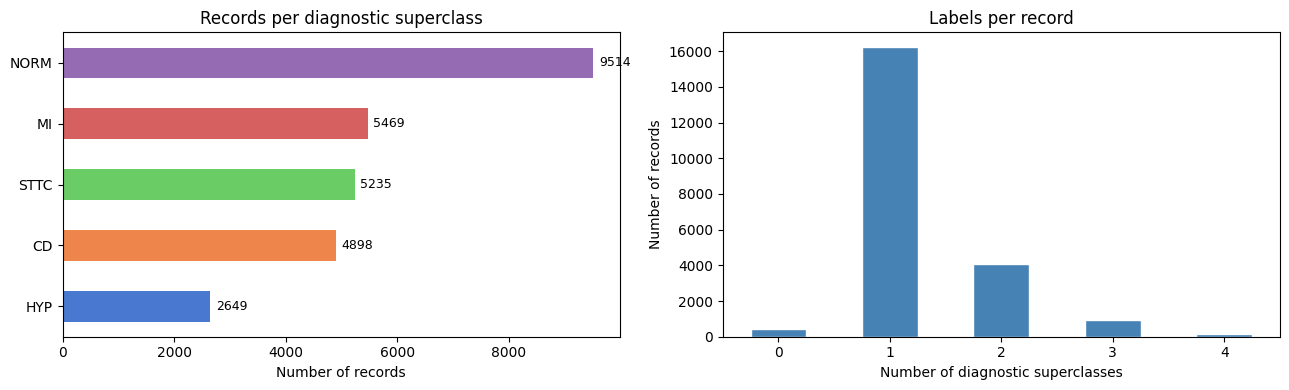

In [7]:
# Visualise class distribution
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Left: superclass counts
cls_series = pd.Series(class_counts).sort_values(ascending=True)
colors = sns.color_palette("muted", len(cls_series))
cls_series.plot(kind='barh', ax=axes[0], color=colors)
axes[0].set_xlabel('Number of records')
axes[0].set_title('Records per diagnostic superclass')
for i, (val, name) in enumerate(zip(cls_series.values, cls_series.index)):
    axes[0].text(val + 100, i, f'{val}', va='center', fontsize=9)

# Right: single vs multi-label breakdown
labels_per_record = Y['n_classes'].value_counts().sort_index()
labels_per_record.plot(kind='bar', ax=axes[1], color='steelblue', edgecolor='white')
axes[1].set_xlabel('Number of diagnostic superclasses')
axes[1].set_ylabel('Number of records')
axes[1].set_title('Labels per record')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=0)

plt.tight_layout()
plt.show()


 **Observations:**



 - NORM (normal) is the largest class. MI (myocardial infarction), STTC (ST/T changes), CD (conduction disturbance), and HYP (hypertrophy) are the pathological classes.

 - About 76% of labeled records have a single superclass, and ~24% have multiple.

 - Some records have no diagnostic label at all — we exclude these fromclassification.



 **Decision**: For our CNN-Transformer, we start with **single-label records only** to simplify the problem (standard multi-class classification with cross-entropy loss). This is a common approach in the PTB-XL literature. We note this as a simplification in the discussion.

 ### Multi-label encoding


We apply multi-label classification (MLC) using sigmoid activations and binary cross-entropy loss, evaluating with subset accuracy, micro-F1, and macro-F1. Each record gets a binary vector indicating which of the 5 diagnostic superclasses are present.

In [8]:
# Define the 5 diagnostic superclasses in a fixed order
n_classes = len(SUPERCLASSES)

# Keep only records that have at least one diagnostic label
Y_labeled = Y[Y['n_classes'] > 0].copy()
mask = Y['n_classes'] > 0
Y_labeled = Y[mask].copy()
X_labeled = X[mask.values]

print(f"Records with diagnostic labels: {len(Y_labeled)}")
print(f"Signal array shape: {X_labeled.shape}")

Y_multilabel = np.vstack([
    build_multilabel_vector(classes, SUPERCLASSES)
    for classes in Y_labeled['diagnostic_superclass']
])

print(f"Multi-label matrix shape: {Y_multilabel.shape}")
print(f"Label distribution:")
for i, cls in enumerate(SUPERCLASSES):
    count = int(Y_multilabel[:, i].sum())
    pct = count / len(Y_multilabel) * 100
    print(f"  {cls:5s}: {count:6d} ({pct:.1f}%)")

# Verify: records with 1, 2, 3+ labels
n_labels_per_record = Y_multilabel.sum(axis=1)
print(f"\nLabels per record:")
for n in sorted(set(n_labels_per_record.astype(int))):
    count = (n_labels_per_record == n).sum()
    print(f"  {n} label(s): {count} records ({count/len(Y_multilabel)*100:.1f}%)")



Records with diagnostic labels: 21388
Signal array shape: (21388, 1000, 12)
Multi-label matrix shape: (21388, 5)
Label distribution:
  CD   :   4898 (22.9%)
  HYP  :   2649 (12.4%)
  MI   :   5469 (25.6%)
  NORM :   9514 (44.5%)
  STTC :   5235 (24.5%)

Labels per record:
  1 label(s): 16244 records (75.9%)
  2 label(s): 4068 records (19.0%)
  3 label(s): 919 records (4.3%)
  4 label(s): 157 records (0.7%)


Understanding which classes co-occur helps us interpret model behavior later, particularly for the interpretability analysis (Task 3).

Most common label combinations:
diagnostic_superclass
NORM               9069
MI                 2532
STTC               2400
CD                 1708
CD + MI            1297
HYP + STTC          781
MI + STTC           599
HYP                 535
CD + STTC           471
CD + NORM           407
HYP + MI + STTC     361
CD + HYP            300
CD + MI + STTC      223
CD + HYP + STTC     211
HYP + MI            183


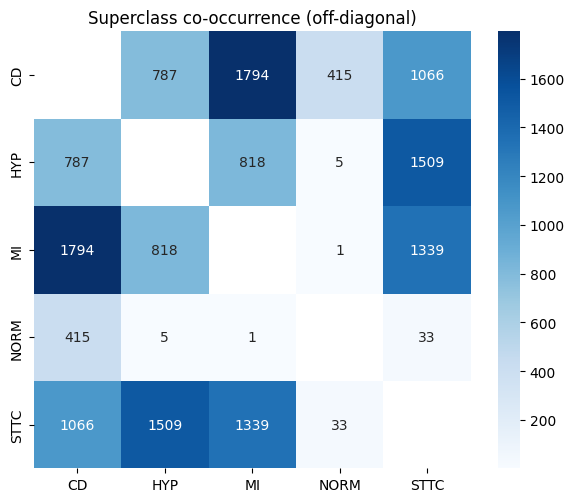

In [9]:
# Analyse co-occurrence patterns
combo_series = Y_labeled['diagnostic_superclass'].apply(lambda x: ' + '.join(sorted(x)))
print("Most common label combinations:")
print(combo_series.value_counts().head(15).to_string())

# Co-occurrence matrix (how often does class i appear with class j?)
cooccurrence = Y_multilabel.T @ Y_multilabel  # (5, 5) matrix
cooccurrence_df = pd.DataFrame(cooccurrence.astype(int),
                                index=SUPERCLASSES, columns=SUPERCLASSES)

fig, ax = plt.subplots(figsize=(6, 5))
# Mask diagonal for clarity (self-co-occurrence = class count)
mask = np.eye(n_classes, dtype=bool)
sns.heatmap(cooccurrence_df, annot=True, fmt='d', cmap='Blues',
            mask=mask, ax=ax, square=True)
ax.set_title('Superclass co-occurrence (off-diagonal)')
plt.tight_layout()
plt.show()

### Train/validation/test split

We use the PTB-XL stratified folds: folds 1–8 for training, fold 9 for validation, fold 10 for testing. This is a patient-level split (no data leakage) and preserves class proportions.

In [10]:
# Apply the recommended split
test_fold = 10
val_fold = 9

# Build masks based on strat_fold
train_mask = Y_labeled['strat_fold'].values <= 8
val_mask = Y_labeled['strat_fold'].values == val_fold
test_mask = Y_labeled['strat_fold'].values == test_fold

X_train = X_labeled[train_mask]
X_val = X_labeled[val_mask]
X_test = X_labeled[test_mask]

y_train = Y_multilabel[train_mask]
y_val = Y_multilabel[val_mask]
y_test = Y_multilabel[test_mask]

print(f"Train: {X_train.shape[0]:>6d} records (folds 1-8)")
print(f"Val:   {X_val.shape[0]:>6d} records (fold 9)")
print(f"Test:  {X_test.shape[0]:>6d} records (fold 10)")

# Verify class balance is preserved across splits
print(f"\nClass prevalence per split (%):")
header = f"{'':>7s}" + "".join(f"{cls:>8s}" for cls in SUPERCLASSES)
print(header)
for name, labels in [('Train', y_train), ('Val', y_val), ('Test', y_test)]:
    pcts = (labels.mean(axis=0) * 100)
    row = f"{name:>7s}" + "".join(f"{p:>8.1f}" for p in pcts)
    print(row)



Train:  17084 records (folds 1-8)
Val:     2146 records (fold 9)
Test:    2158 records (fold 10)

Class prevalence per split (%):
             CD     HYP      MI    NORM    STTC
  Train    22.9    12.4    25.6    44.5    24.5
    Val    23.1    12.5    25.2    44.5    24.6
   Test    23.0    12.1    25.5    44.6    24.1


In [11]:
# Skip preprocessing and feature extraction if cached data is available

if USE_CACHED:
    print("Loading preprocessed data from processed_data/...")
    X_train_proc = np.load('processed_data/X_train_proc.npy')
    X_val_proc = np.load('processed_data/X_val_proc.npy')
    X_test_proc = np.load('processed_data/X_test_proc.npy')
    y_train = np.load('processed_data/y_train.npy')
    y_val = np.load('processed_data/y_val.npy')
    y_test = np.load('processed_data/y_test.npy')
    feat_train = pd.read_csv('processed_data/feat_train.csv')
    feat_val = pd.read_csv('processed_data/feat_val.csv')
    feat_test = pd.read_csv('processed_data/feat_test.csv')
    print(f"  Signals: train={X_train_proc.shape}, val={X_val_proc.shape}, test={X_test_proc.shape}")
    print("Done — skip preprocessing and feature extraction cells below.")
else:
    print("No cached data found — run all preprocessing cells below.")

Loading preprocessed data from processed_data/...
  Signals: train=(17084, 1000, 12), val=(2146, 1000, 12), test=(2158, 1000, 12)
Done — skip preprocessing and feature extraction cells below.


## Task 2: Data Understanding, Feature Extraction and Visualization

### Demographics and signal exploration

We look at the demograpics of the patients in the dataset. This helps us ontextualise the results and see if there are any potential biases.

Text(0.5, 1.0, 'Top 20 recording sites')

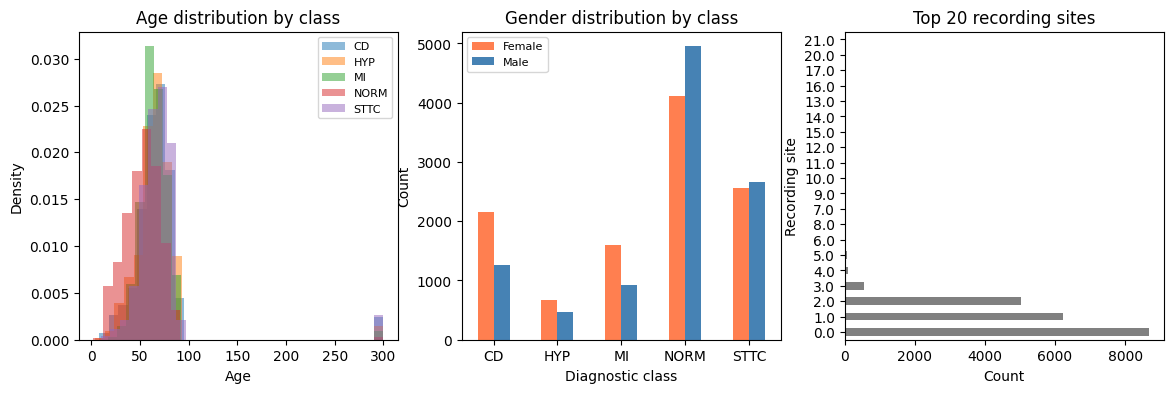

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# For demographics, assign a "primary" label (first in list) for grouping
Y_labeled['primary_label'] = Y_labeled['diagnostic_superclass'].apply(lambda x: x[0])

# Age distribution by class
for label in sorted(SUPERCLASSES):
    subset = Y_labeled[Y_labeled['primary_label'] == label]
    axes[0].hist(subset['age'].dropna(), bins=30, alpha=0.5, label=label, density=True)
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Density')
axes[0].set_title('Age distribution by class')
axes[0].legend(fontsize=8)

# Gender distribution
gender_by_class = Y_labeled.groupby(['primary_label', 'sex']).size().unstack(fill_value=0)
gender_by_class.columns = ['Female', 'Male']
gender_by_class.plot(kind='bar', ax=axes[1], color=['coral', 'steelblue'])
axes[1].set_xlabel('Diagnostic class')
axes[1].set_ylabel('Count')
axes[1].set_title('Gender distribution by class')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=0)
axes[1].legend(fontsize=8)

# Recording site distribution
top_n = 20
site_counts = Y_labeled['site'].value_counts().head(top_n)
site_counts.plot(kind='barh', ax=axes[2], color='gray')
axes[2].set_xlabel('Count')
axes[2].set_ylabel('Recording site')
axes[2].set_title(f'Top {top_n} recording sites')

Before preprocessing, we want to see what the raw ECG signal actually looks like for each diagnostic superclass. This gives us visual intuition for what the model needs to learn to distinguish. We choose to plot **Lead II**.

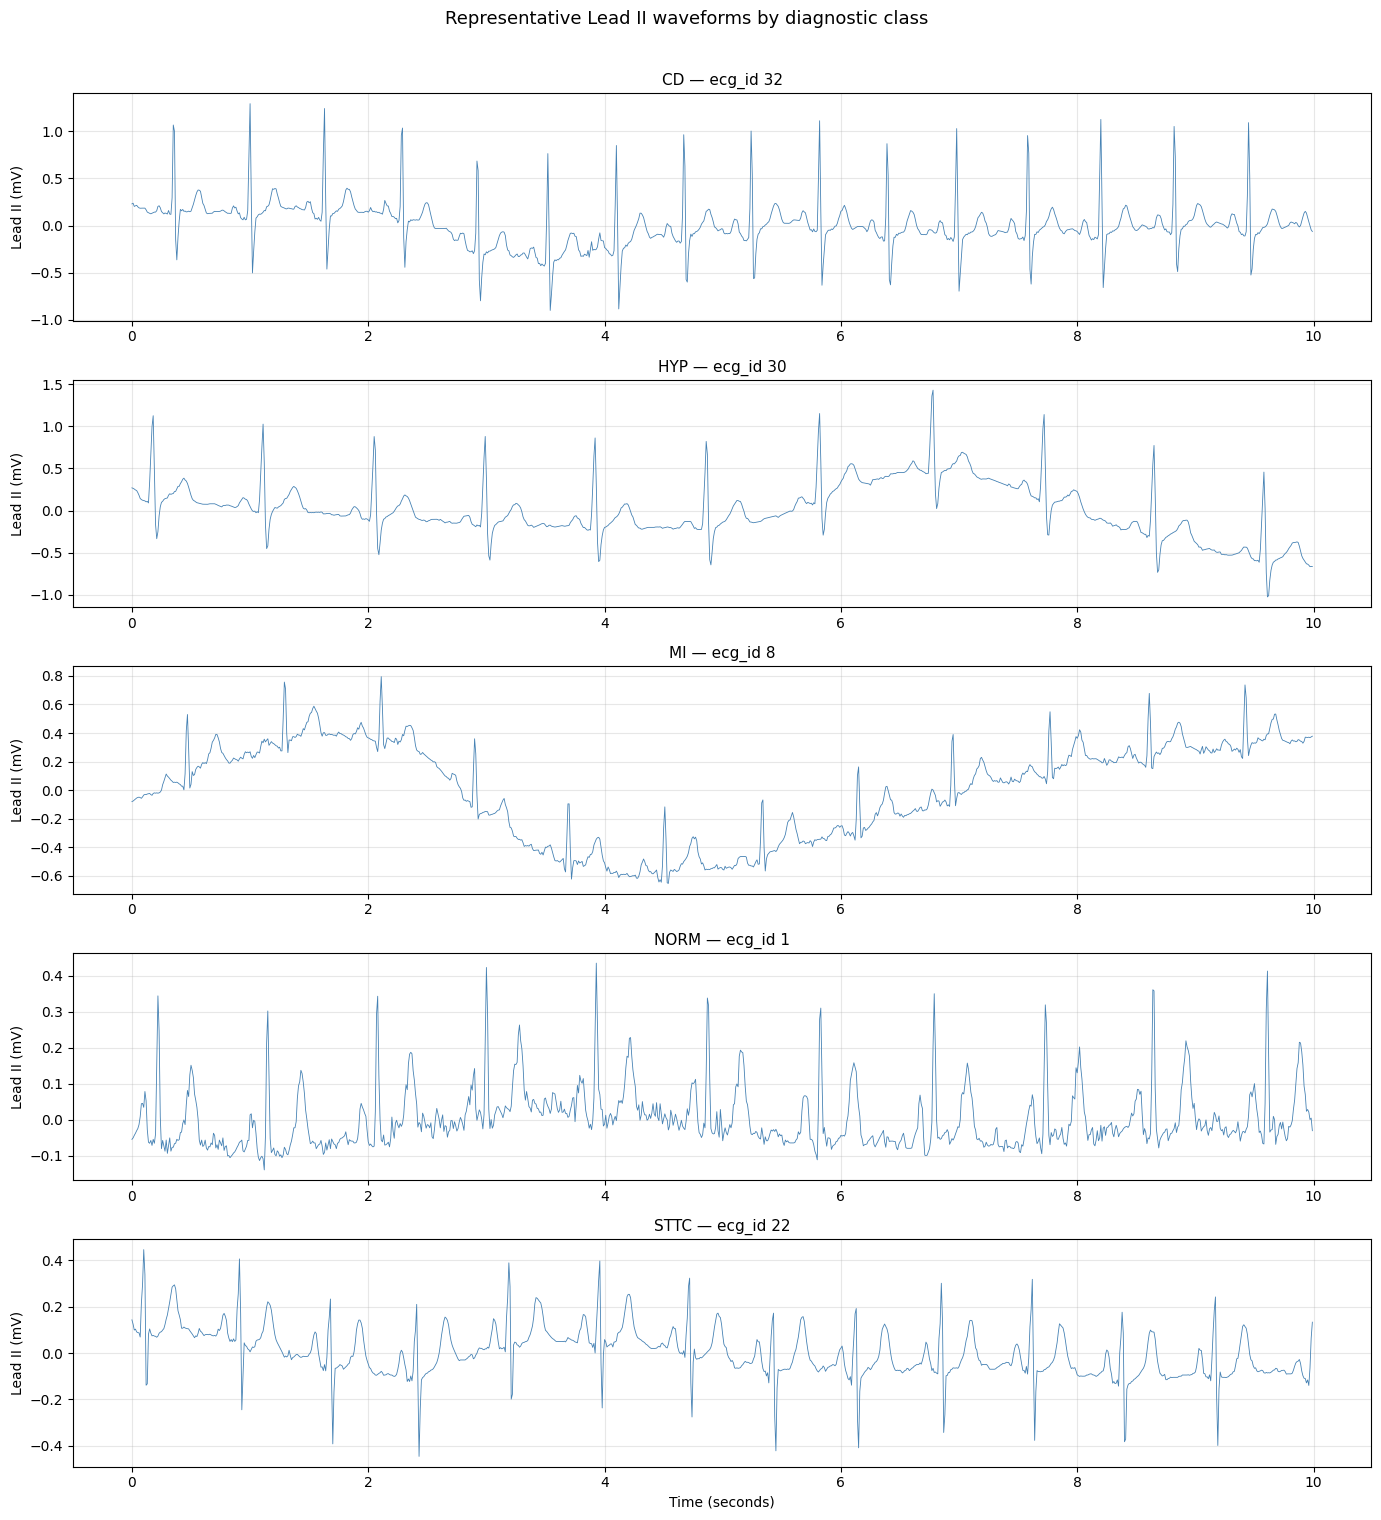

In [13]:
# Pick one example per class
class_examples = {}
for label in sorted(SUPERCLASSES):
    # Find a single-label record for a clean example
    candidates = Y_labeled[
        Y_labeled['diagnostic_superclass'].apply(lambda x: x == [label])
    ]
    if len(candidates) == 0:
        candidates = Y_labeled[
            Y_labeled['diagnostic_superclass'].apply(lambda x: label in x)
        ]
    idx = candidates.index[0]
    arr_idx = np.where(Y_labeled.index == idx)[0][0]
    class_examples[label] = (idx, arr_idx)

# Plot lead II for each class
fig, axes = plt.subplots(len(class_examples), 1, figsize=(14, 3 * len(class_examples)))
t = np.arange(1000) / sampling_rate

for ax, (label, (ecg_id, arr_idx)) in zip(axes, class_examples.items()):
    signal = X_labeled[arr_idx, :, 1]
    ax.plot(t, signal, linewidth=0.6, color='steelblue')
    ax.set_ylabel('Lead II (mV)')
    ax.set_title(f'{label} — ecg_id {ecg_id}', fontsize=11)
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel('Time (seconds)')
fig.suptitle('Representative Lead II waveforms by diagnostic class', fontsize=13, y=1.01)
plt.tight_layout()

plt.show()



The five superclasses show different signal characteristics, even in this single lead:

- **NORM** has a clean, low-amplitude signal with very regular rhythm and consistent *P-QRS-T*: a normal looking sinus rhythm.
- **HYP** shows the tallest R-wave peaks (up to ~1.5 mV), consistent with *ventricular hypertrophy*: a thicker heart muscle produces larger voltage during depolarisation.
- **CD** displays wider, more irregular QRS complexes. The beat-to-beat morphology varies, suggesting the electrical conduction pathway is disrupted.
- **MI** is the most visually striking — there is a large baseline shift in the middle of the recording where the signal drops substantially. This kind of ST-segment deviation is a hallmark of ischemic damage.
- **STTC** looks superficially similar to NORM in amplitude and rhythm, but the waveform shape between beats differs — the T-waves and ST-segments have altered morphology. This will likely be the hardest pair for the model to separate.

Next we look at the full 12-lead view a single NORM (normal healthy heart-rythm) and a single MI (myocardial infarct) record

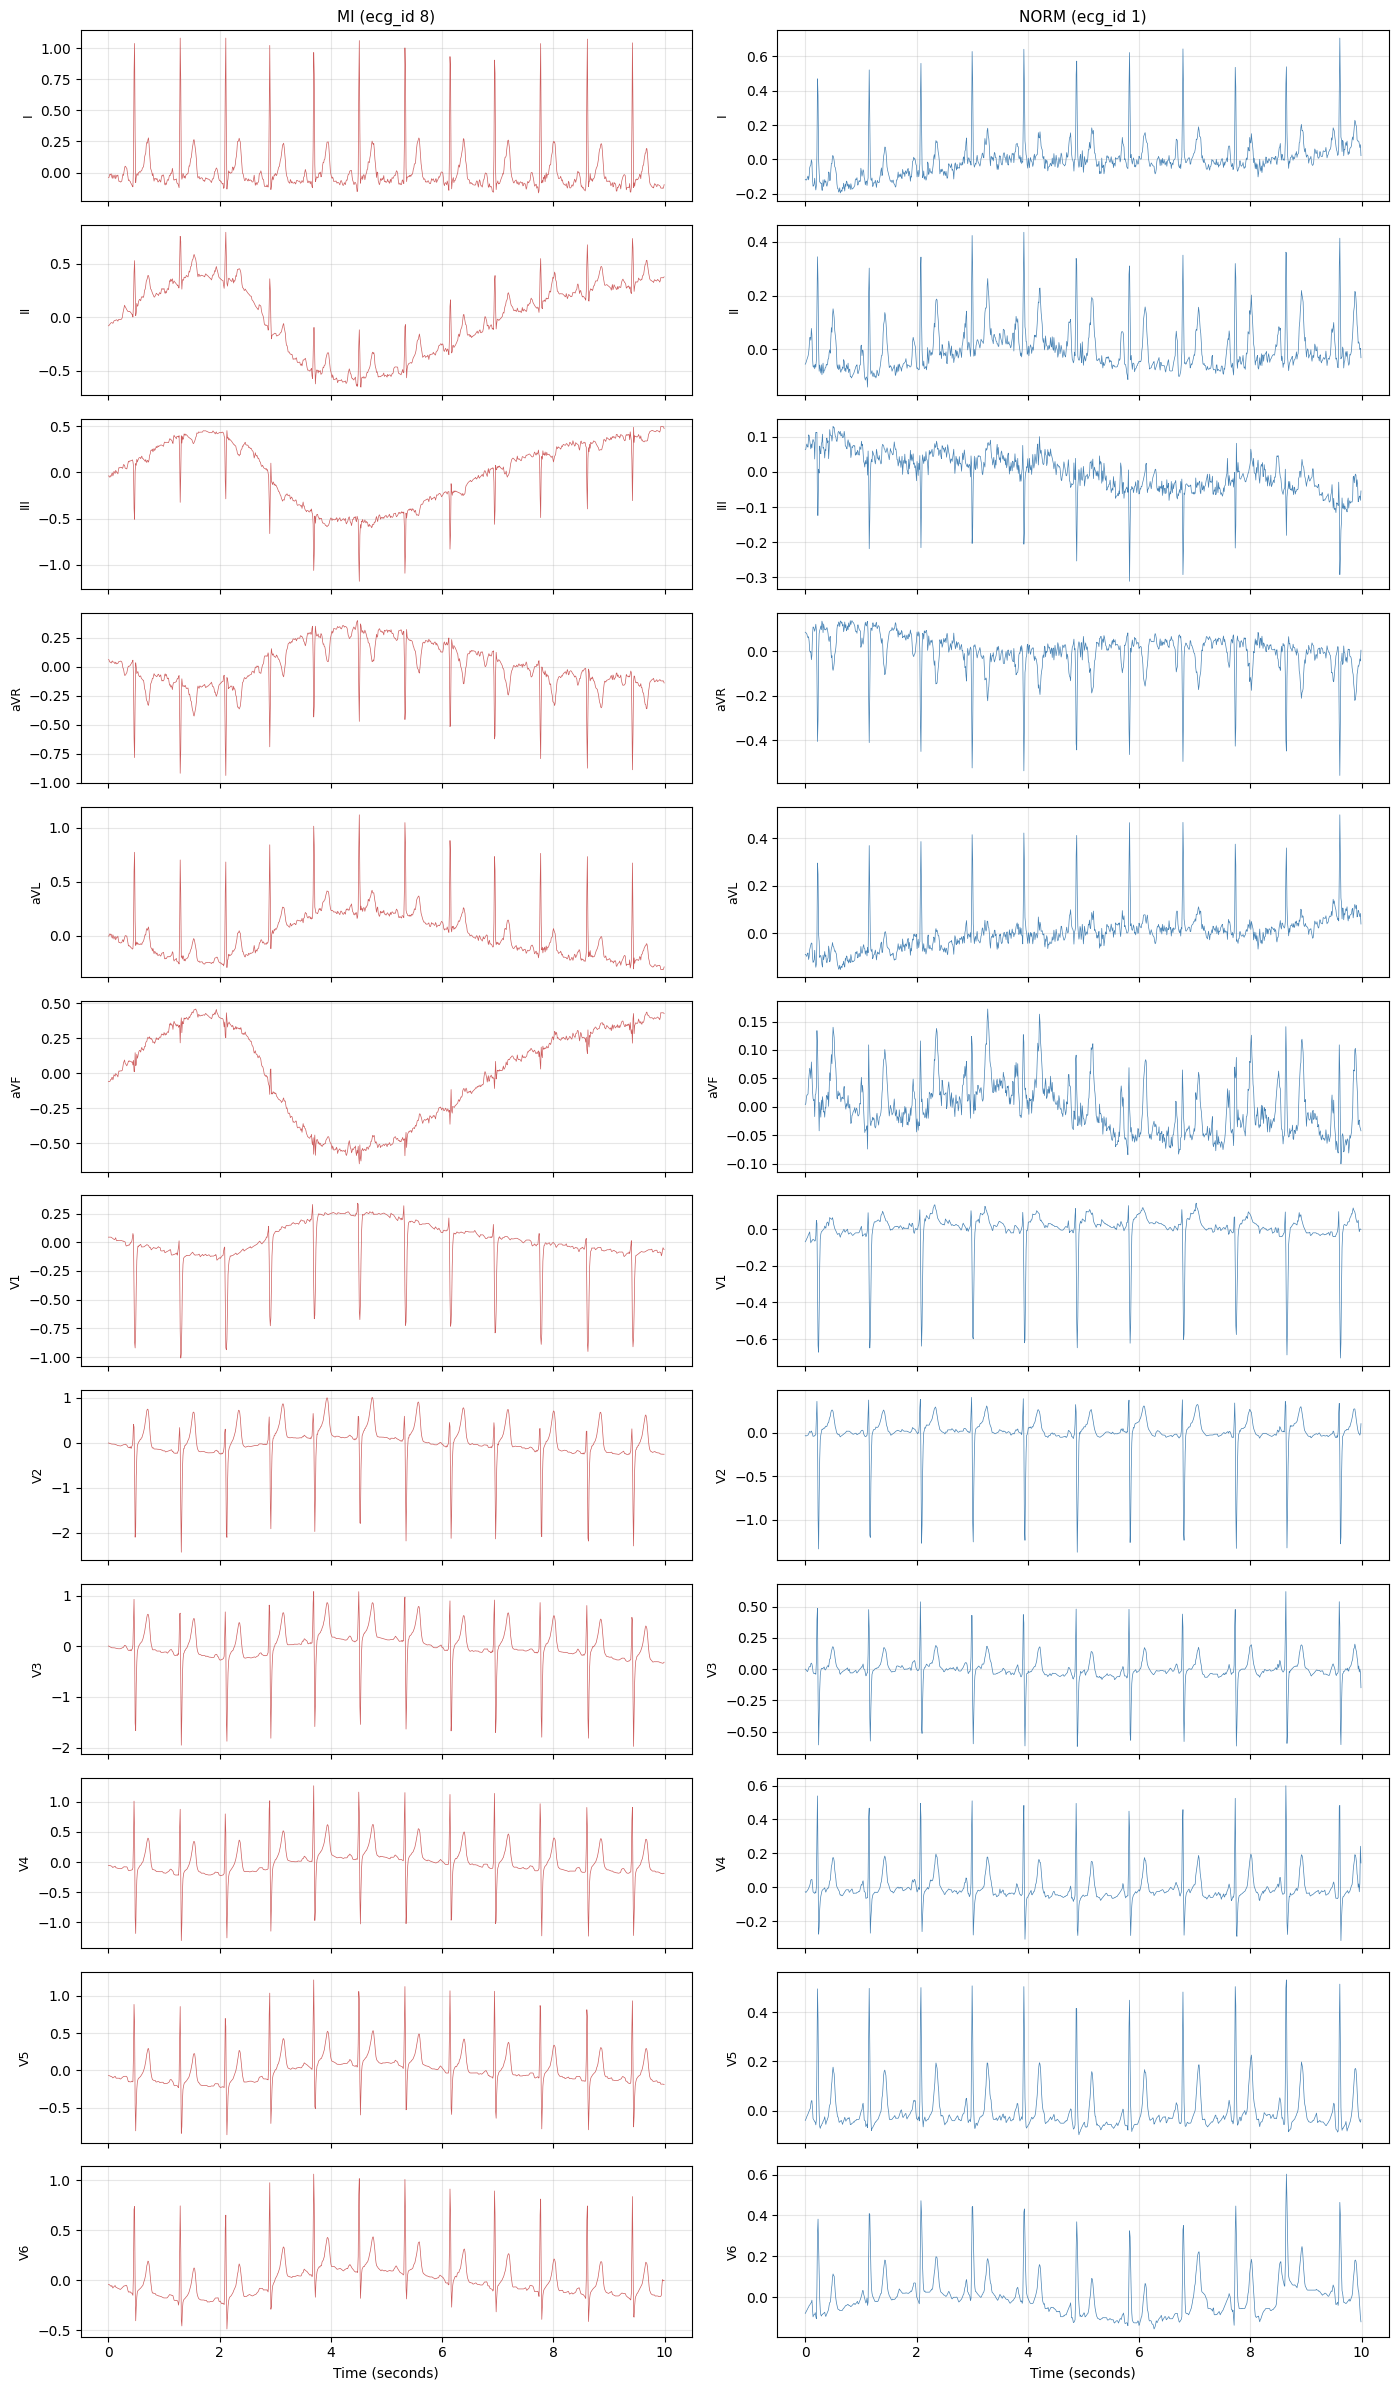

In [14]:
# Detailed 12-lead view for a single NORM and a single MI record
fig, axes = plt.subplots(12, 2, figsize=(14, 24), sharex=True)

for col, (label, (ecg_id, arr_idx)) in enumerate(
    [(k, v) for k, v in class_examples.items() if k in ['NORM', 'MI']]
):
    for lead_idx in range(12):
        ax = axes[lead_idx, col]
        signal = X_labeled[arr_idx, :, lead_idx]
        ax.plot(t, signal, linewidth=0.5, color='steelblue' if label == 'NORM' else 'indianred')
        ax.set_ylabel(LEAD_NAMES[lead_idx], fontsize=9)
        ax.grid(True, alpha=0.3)
        if lead_idx == 0:
            ax.set_title(f'{label} (ecg_id {ecg_id})', fontsize=11)

axes[-1, 0].set_xlabel('Time (seconds)')
axes[-1, 1].set_xlabel('Time (seconds)')
plt.tight_layout()
plt.show()


We check the raw signal characteristics: value ranges, presence of NaNs, and whether the amplitudes vary significantly across records. This informs our normalisation strategy.

In [15]:
# Check for NaN values in the raw data
n_nan_records = np.isnan(X_labeled).any(axis=(1, 2)).sum()
total_nans = np.isnan(X_labeled).sum()
print(f"Records with any NaN: {n_nan_records}/{len(X_labeled)}")
print(f"Total NaN values: {total_nans}")

# Per-lead statistics (computed on training set only to avoid leakage)
print(f"\nPer-lead statistics (training set):")
print(f"{'Lead':<6s} {'Mean':>8s} {'Std':>8s} {'Min':>8s} {'Max':>8s}")
print("-" * 42)
for i, name in enumerate(LEAD_NAMES):
    vals = X_train[:, :, i].flatten()
    vals = vals[~np.isnan(vals)]  # ignore NaNs
    print(f"{name:<6s} {vals.mean():>8.3f} {vals.std():>8.3f} {vals.min():>8.3f} {vals.max():>8.3f}")


Records with any NaN: 0/21388
Total NaN values: 0

Per-lead statistics (training set):
Lead       Mean      Std      Min      Max
------------------------------------------
I        -0.002    0.160   -7.455    4.398
II       -0.002    0.159   -5.856    5.576
III       0.000    0.160   -4.451    7.491
aVR       0.002    0.138   -2.972    5.920
aVL      -0.001    0.139   -7.473    4.425
aVF      -0.001    0.138   -5.300    5.553
V1        0.000    0.234  -17.825   10.547
V2       -0.001    0.334  -11.102   12.157
V3       -0.002    0.328  -16.320    8.505
V4       -0.001    0.293  -11.198    8.383
V5       -0.001    0.272  -13.055   17.212
V6       -0.002    0.281  -20.032    9.078


### PTB-XL+ clinical features
The [PTB-XL+ dataset](https://physionet.org/content/ptb-xl-plus/1.0.1/) provides pre-computed clinical features extracted by three different algorithms:

 - **12SL**: GE Marquette 12SL algorithm features
 - **ecgdeli**: Open-source ECG delineation features
 - **unig**: University of Glasgow features

The features represent clinically meaningful measurements (intervals, amplitudes, axes) that cardiologists use for diagnosis. We use them for:

1. Understanding what clinical features distinguish the classes (EDA)

2. Building a baseline feature-based classifier (before deep learning)

In [16]:
# Load the feature datasets
twelve_sl_df = pd.read_csv(FEATURES_DIR / '12sl_features.csv')
ecgdeli_df = pd.read_csv(FEATURES_DIR / 'ecgdeli_features.csv')
feature_desc_df = pd.read_csv(FEATURES_DIR / 'feature_description.csv')
unig_df = pd.read_csv(FEATURES_DIR / 'unig_features.csv')

print(f"12SL features:    {twelve_sl_df.shape}")
print(f"ecgdeli features: {ecgdeli_df.shape}")
print(f"unig features:    {unig_df.shape}")
print(f"\nFeature descriptions: {feature_desc_df.shape}")
print(feature_desc_df.head(10).to_string())


12SL features:    (21799, 783)
ecgdeli features: (21799, 532)
unig features:    (21795, 749)

Feature descriptions: (195, 10)
            id                                                         unig_feature                                 12sl_feature ecgdeli_feature                              description                                                                                           Loinc_concept_ids unit                       comment  consistent_units_unig  consistent_units_12sl
0      P_Amp_X                              $ P+_Amp_X if P_Morph_X>0 else P-_Amp_X                                 P_PeakAmpl_X           PWa_X               P wave amplitude in lead X  3024893, 3025405, 3026247, 3012776, 3027068, 3012976, 3010691, 3014384, 3025329, 3011867, 3025534, 3006830   mV                           NaN                  0.001                  0.001
1  P_DurFull_X                                                          ILM_P_Dur_X                           $ P_Dur_X+Pp_D

In [17]:
# Check overlap with our single-label subset
print(f"\nRecords in 12SL features: {len(twelve_sl_df)}")
print(f"Records in our subset:    {len(Y_labeled)}")

# Merge 12SL features with our labels for EDA
# 12SL uses ecg_id as identifier
if 'ecg_id' in twelve_sl_df.columns:
    feat_with_labels = twelve_sl_df.merge(
        Y_labeled[['primary_label', 'strat_fold', 'age', 'sex']],
        left_on='ecg_id', right_index=True, how='inner'
    )
    print(f"Matched records: {len(feat_with_labels)}")
    
    # Show a few key clinical features by class
    # Heart rate, QRS duration, and QT interval are among the most
    # diagnostically relevant ECG measurements
    clinical_cols = [c for c in feat_with_labels.columns 
                     if any(term in c.lower() for term in ['heart_rate', 'qrs_dur', 'qt_', 'pr_'])]
    
    if clinical_cols:
        print(f"\nKey clinical features (first 6):")
        for col in clinical_cols[:6]:
            print(f"\n  {col}:")
            print(feat_with_labels.groupby('primary_label')[col].describe()[['mean', 'std']].round(2).to_string())



Records in 12SL features: 21799
Records in our subset:    21388
Matched records: 21388

Key clinical features (first 6):

  QRS_Dur_Global:
                 mean    std
primary_label               
CD             115.06  26.13
HYP            105.33  23.49
MI              93.26  11.76
NORM            90.31   9.84
STTC            95.41  14.20

  QT_Int_Global:
                 mean    std
primary_label               
CD             403.96  42.13
HYP            400.38  39.78
MI             394.95  38.93
NORM           394.79  30.14
STTC           389.86  45.17

  QT_IntBazett_Global:
                 mean    std
primary_label               
CD             445.63  36.68
HYP            441.40  34.57
MI             433.36  29.58
NORM           422.37  23.21
STTC           438.42  35.45

  PR_Int_Global:
                 mean    std
primary_label               
CD             176.52  35.83
HYP            173.67  30.90
MI             167.51  24.91
NORM           159.27  22.44
STTC           1

### MIT-BIH Long-Term ECG Database (overview)

The structure of this dataset is very different from PTB-XL:



| Property | PTB-XL | MIT-BIH LTDB |
|----------|--------|--------------|
| Records | 21,837 | 7 |
| Duration | 10 sec each | 14–24 hours each |
| Leads | 12 | 2 |
| Sampling | 100/500 Hz | 128 Hz |
| Labels | Diagnostic superclass | Beat-level annotations |
| Use case | Training | Generalizability testing |

We will not train on MIT-BIH directly. Instead, we will:
1. Segment the long recordings into windows
2. Apply our PTB-XL-trained model to these segments
3. Evaluate whether learned representations transfer

For now, we just confirm we can read the data.

In [18]:
# List available MIT-BIH LTDB records
mit_files = sorted([f.replace('.hea', '') for f in os.listdir(MIT_BIH_DATA) 
                     if f.endswith('.hea')])
print(f"MIT-BIH LTDB records: {len(mit_files)}")
for f in mit_files:
    try:
        hdr = wfdb.rdheader(str(MIT_BIH_DATA / f))
        duration_hrs = hdr.sig_len / hdr.fs / 3600
        print(f"  {f}: {hdr.n_sig} leads, {hdr.fs} Hz, "
              f"{hdr.sig_len:,} samples ({duration_hrs:.1f} hours), "
              f"leads: {hdr.sig_name}")
    except Exception as e:
        print(f"  {f}: Error — {e}")


MIT-BIH LTDB records: 7
  14046: 2 leads, 128 Hz, 10,828,800 samples (23.5 hours), leads: ['ECG1', 'ECG2']
  14134: 2 leads, 128 Hz, 6,420,480 samples (13.9 hours), leads: ['ECG1', 'ECG2']
  14149: 2 leads, 128 Hz, 10,997,760 samples (23.9 hours), leads: ['ECG1', 'ECG2']
  14157: 2 leads, 128 Hz, 9,454,080 samples (20.5 hours), leads: ['ECG1', 'ECG2']
  14172: 2 leads, 128 Hz, 9,753,600 samples (21.2 hours), leads: ['ECG1', 'ECG2']
  14184: 2 leads, 128 Hz, 10,252,800 samples (22.2 hours), leads: ['ECG1', 'ECG2']
  15814: 3 leads, 128 Hz, 10,237,440 samples (22.2 hours), leads: ['ECG1', 'ECG2', 'ECG3']


### Preprocessing Pipeline

Based on our exploration, we define the preprocessing for PTB-XL signals. Our time series analysis pipeline will consist of these steps (following): Data collection → Preprocessing → Segmentation → Feature extraction → Classification). For preprocessing, the steps are:

1. **Handling NaNs**: Replace any NaN values with 0 (rare in PTB-XL)

2. **Filtering**: Bandpass filter to isolate clinically relevant frequencies

   - ECG: 0.5–40 Hz bandpass (removes baseline drift + high-freq noise)

   - This is gentler than the VTaC filters since we want to preserve more morphological detail for the CNN

 3. **Normalisation**: Per-record z-score normalisation

   (same rationale as Assignment 1: different patients, devices, electrode placements produce different absolute amplitudes)

We keep all 12 leads — unlike Assignment 1 where we reduced to 4 channels, here we have a consistent 12-lead setup across all records.

In [19]:
# Apply preprocessing to each split separately
# (filtering and z-score are per-record, so no leakage concern,
# but we keep the splits separate for clarity)
print("Preprocessing training set...")
X_train_proc = preprocess_ptbxl(X_train, sampling_rate)

print("\nPreprocessing validation set...")
X_val_proc = preprocess_ptbxl(X_val, sampling_rate)

print("\nPreprocessing test set...")
X_test_proc = preprocess_ptbxl(X_test, sampling_rate)

print(f"\nFinal shapes:")
print(f"  X_train: {X_train_proc.shape}")
print(f"  X_val:   {X_val_proc.shape}")
print(f"  X_test:  {X_test_proc.shape}")


Preprocessing training set...
  Applying bandpass filter: 0.5–40.0 Hz
  Applying per-record z-score normalisation

Preprocessing validation set...
  Applying bandpass filter: 0.5–40.0 Hz
  Applying per-record z-score normalisation

Preprocessing test set...
  Applying bandpass filter: 0.5–40.0 Hz
  Applying per-record z-score normalisation

Final shapes:
  X_train: (17084, 1000, 12)
  X_val:   (2146, 1000, 12)
  X_test:  (2158, 1000, 12)


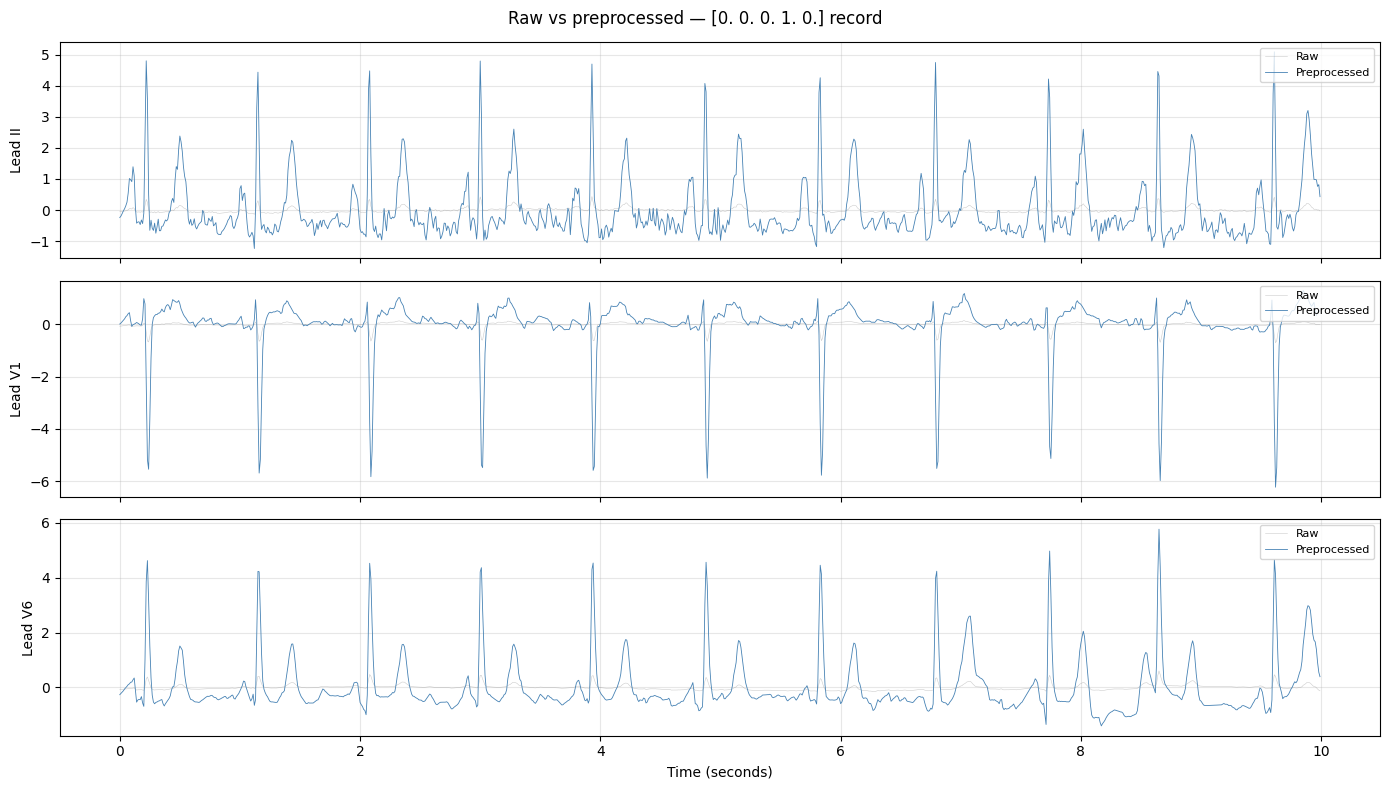

In [20]:
# Visualise preprocessing effect on one record
example_idx = 0
fig, axes = plt.subplots(3, 1, figsize=(14, 8), sharex=True)
t = np.arange(1000) / sampling_rate

for ax, (lead_idx, lead_name) in zip(axes, [(1, 'II'), (6, 'V1'), (11, 'V6')]):
    ax.plot(t, X_train[example_idx, :, lead_idx], alpha=0.4, linewidth=0.4,
            label='Raw', color='gray')
    ax.plot(t, X_train_proc[example_idx, :, lead_idx], linewidth=0.6,
            label='Preprocessed', color='steelblue')
    ax.set_ylabel(f'Lead {lead_name}')
    ax.legend(loc='upper right', fontsize=8)
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel('Time (seconds)')
fig.suptitle(f'Raw vs preprocessed — {y_train[example_idx]} record', fontsize=12)
plt.tight_layout()
plt.show()


### Preprocessing summary

| Step | Method | Rationale |
|------|--------|-----------|
| NaNs | Replace with 0 | Rare in PTB-XL; prevents filter errors |
| Filtering | 0.5–40 Hz bandpass, order 2 Butterworth | Removes drift + HF noise, preserves QRS |
| Normalisation | Per-record, per-lead z-score | Accounts for inter-patient amplitude variation |

All 12 leads are preserved. No records are dropped.

The preprocessed data is ready for feature extraction and direct input to the CNN-Transformer.

### Feature extraction from preprocessed signals


We extract two types of features per lead, following the course slides' recommendation of "signal-based features" (mean, variance, kurtosis, etc.):


**Time-domain features** (per lead):

- Mean, standard deviation, skewness, kurtosis

- Min, max, range (peak-to-peak amplitude)

- Root mean square (RMS)

- Zero-crossing rate (related to signal frequency content)


**Frequency-domain features** (per lead):

- Dominant frequency (highest-power frequency component)

- Power in clinically relevant bands:

- 0.5–4 Hz (low frequency — baseline, P/T waves)

- 4–15 Hz (mid frequency — QRS complex energy)

- 15–40 Hz (high frequency — fine morphology, noise)

This gives us 13 features × 12 leads = 156 features per record. These are deliberately simple — the point is to show what hand-crafted features can and cannot capture, compared to learned CNN features.

In [21]:
print("Extracting features from preprocessed signals...")
print("  Training set...")
feat_train = extract_signal_features(X_train_proc, sampling_rate)
print("  Validation set...")
feat_val = extract_signal_features(X_val_proc, sampling_rate)
print("  Test set...")
feat_test = extract_signal_features(X_test_proc, sampling_rate)

print(f"\nFeature matrix shapes:")
print(f"  Train: {feat_train.shape}")
print(f"  Val:   {feat_val.shape}")
print(f"  Test:  {feat_test.shape}")

# Check for NaN/inf values
n_nan = feat_train.isna().sum().sum()
n_inf = np.isinf(feat_train.values).sum()
print(f"\nData quality: {n_nan} NaN, {n_inf} inf values in training features")

Extracting features from preprocessed signals...
  Training set...
  Validation set...
  Test set...

Feature matrix shapes:
  Train: (17084, 156)
  Val:   (2146, 156)
  Test:  (2158, 156)

Data quality: 2 NaN, 0 inf values in training features


In [22]:
# Handle any NaN/inf from edge cases (e.g., constant signal → zero std)
for df in [feat_train, feat_val, feat_test]:
    df.replace([np.inf, -np.inf], np.nan, inplace=True)
    df.fillna(0, inplace=True)

### Feature visualization

Before modelling, we visualize which features differ most across classes. This helps us understand what the baseline models will (and won't) capture.

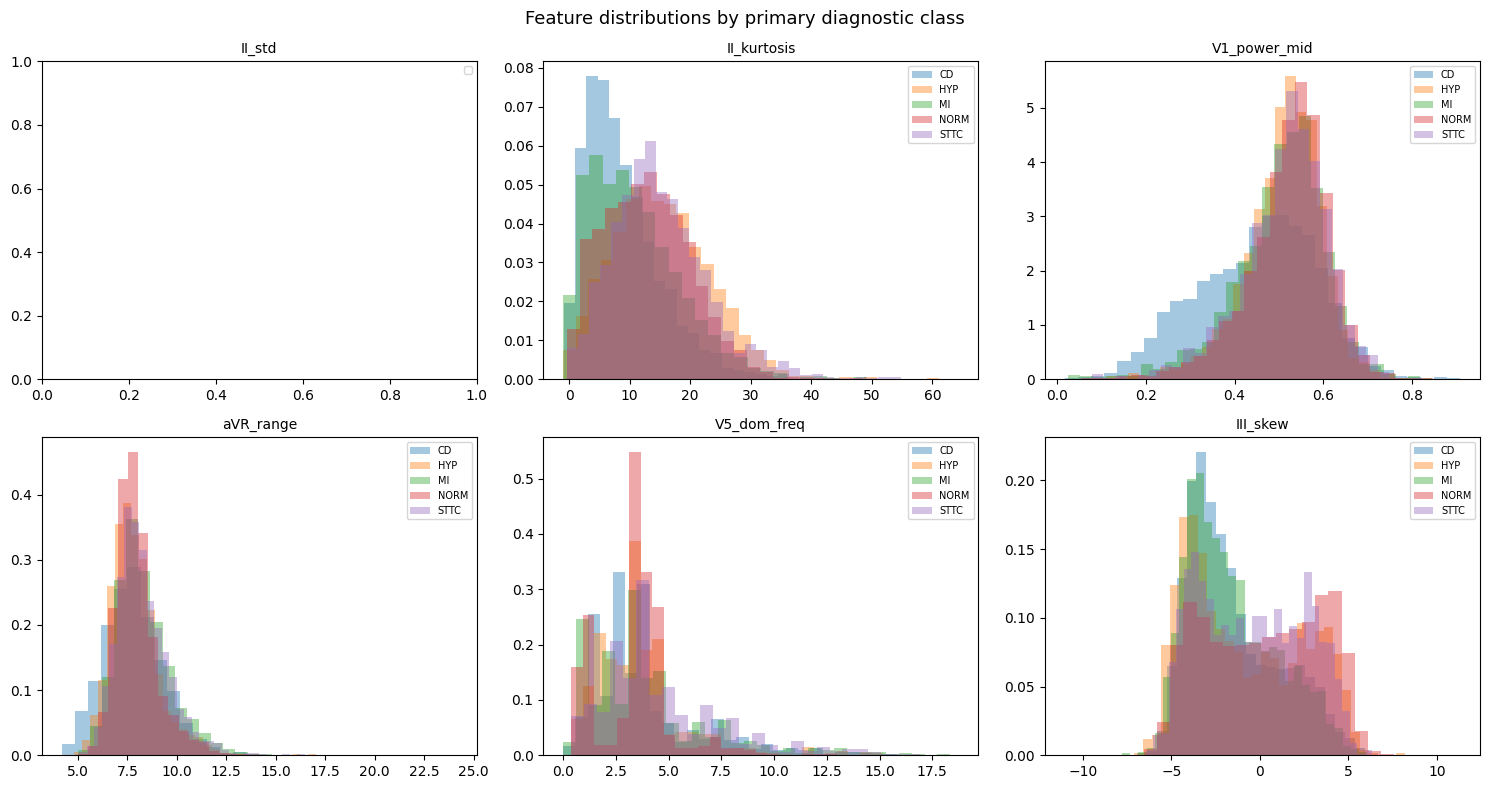

In [28]:
# For visualization, assign primary label to each training record
# (for multi-label records, use the first listed class)
train_primary = [SUPERCLASSES[np.argmax(y_train[i])] for i in range(len(y_train))]

# Find features with highest variance ratio (between-class / within-class)
feat_with_labels = feat_train.copy()
feat_with_labels['primary_class'] = train_primary

# Pick a few interesting features to visualize
viz_features = [
    'II_std', 'II_kurtosis', 'V1_power_mid', 'aVR_range',
    'V5_dom_freq', 'III_skew'
]
# Only use features that exist
viz_features = [f for f in viz_features if f in feat_train.columns]

if len(viz_features) >= 4:
    fig, axes = plt.subplots(2, 3, figsize=(15, 8))
    for ax, feat_name in zip(axes.ravel(), viz_features):
        for cls in SUPERCLASSES:
            subset = feat_with_labels[feat_with_labels['primary_class'] == cls]
            try:
                ax.hist(subset[feat_name].dropna(), bins=30, alpha=0.4, label=cls, density=True)
            except Exception:
                pass
        ax.set_title(feat_name, fontsize=10)
        ax.legend(fontsize=7)
    plt.suptitle('Feature distributions by primary diagnostic class', fontsize=13)
    plt.tight_layout()
    plt.show()

The PTB-XL+ dataset provides pre-computed clinical features from three algorithms.  We merge them with our extracted features to see if this will improve the baseline.

In [29]:
# Attempt to load and merge PTB-XL+ features
try:
    twelve_sl_df = pd.read_csv(FEATURES_DIR / '12sl_features.csv')
    
    # 12SL features are indexed by ecg_id — merge with our labeled subset
    # We need to align with the same train/val/test split
    twelve_sl_df = twelve_sl_df.set_index('ecg_id')
    
    # Get the ecg_ids for each split
    train_ids = Y_labeled[Y_labeled['strat_fold'] <= 8].index
    val_ids = Y_labeled[Y_labeled['strat_fold'] == val_fold].index
    test_ids = Y_labeled[Y_labeled['strat_fold'] == test_fold].index
    
    # Extract matching rows (some ecg_ids might not have 12SL features)
    clinical_train = twelve_sl_df.reindex(train_ids).reset_index(drop=True)
    clinical_val = twelve_sl_df.reindex(val_ids).reset_index(drop=True)
    clinical_test = twelve_sl_df.reindex(test_ids).reset_index(drop=True)
    
    # Drop non-numeric columns
    clinical_cols = clinical_train.select_dtypes(include=[np.number]).columns.tolist()
    clinical_train = clinical_train[clinical_cols]
    clinical_val = clinical_val[clinical_cols]
    clinical_test = clinical_test[clinical_cols]
    
    # Handle missing values
    for df in [clinical_train, clinical_val, clinical_test]:
        df.fillna(0, inplace=True)
    
    print(f"PTB-XL+ (12SL) features loaded: {clinical_train.shape[1]} features")
    print(f"  Matched train: {len(clinical_train)}, val: {len(clinical_val)}, test: {len(clinical_test)}")
    
    has_clinical = True
    
except Exception as e:
    print(f"PTB-XL+ features not available: {e}")
    print("Proceeding with signal-extracted features only.")
    has_clinical = False

PTB-XL+ (12SL) features loaded: 782 features
  Matched train: 17084, val: 2146, test: 2158


### Baseline models

For multi-label classification with sklearn, we use `OneVsRestClassifier` which trains one binary classifier per class.

We evaluate two models:

- **Logistic Regression**: linear baseline, same as Assignment 1
- **Random Forest**: non-linear, captures feature interactions

Both use the multi-label evaluation metrics: subset accuracy, micro-F1, macro-F1, hamming loss.

In [30]:
# Scale features (important for logistic regression)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(feat_train)
X_val_scaled = scaler.transform(feat_val)
X_test_scaled = scaler.transform(feat_test)

# Define models
models = {
    'Logistic Regression': OneVsRestClassifier(
        LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
    ),
    'Random Forest': OneVsRestClassifier(
        RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=42)
    ),
}

# Train and evaluate on signal-extracted features
print("=" * 60)
print("BASELINE RESULTS: Signal-extracted features")
print("=" * 60)

results = []
for name, model in models.items():
    # Use scaled features for LR, unscaled for RF
    X_tr = X_train_scaled if 'Logistic' in name else feat_train.values
    X_te = X_test_scaled if 'Logistic' in name else feat_test.values
    
    model.fit(X_tr, y_train)
    y_pred = model.predict(X_te)
    
    metrics, per_label = eval_multilabel(y_test, y_pred, SUPERCLASSES)
    results.append({'model': name, 'features': 'signal', **metrics})
    
    print(f"\n{name}:")
    print(f"  Subset accuracy: {metrics['subset_accuracy']:.3f}")
    print(f"  Micro-F1:        {metrics['micro_f1']:.3f}")
    print(f"  Macro-F1:        {metrics['macro_f1']:.3f}")
    print(f"  Hamming loss:    {metrics['hamming_loss']:.4f}")
    print(f"  Per-class F1:")
    for _, row in per_label.iterrows():
        print(f"    {row['label']:>5s}: {row['f1']:.3f}")

BASELINE RESULTS: Signal-extracted features

Logistic Regression:
  Subset accuracy: 0.368
  Micro-F1:        0.635
  Macro-F1:        0.603
  Hamming loss:    0.2293
  Per-class F1:
     NORM: 0.785
       CD: 0.653
     STTC: 0.632
       MI: 0.565
      HYP: 0.380

Random Forest:
  Subset accuracy: 0.440
  Micro-F1:        0.582
  Macro-F1:        0.455
  Hamming loss:    0.1725
  Per-class F1:
     NORM: 0.781
       CD: 0.619
     STTC: 0.422
       MI: 0.387
      HYP: 0.066


### Baseline with PTB-XL+ clinical features

In [31]:
if has_clinical:
    # Combine signal features + clinical features
    X_train_combined = np.hstack([X_train_scaled, 
                                   StandardScaler().fit_transform(clinical_train)])
    X_test_combined = np.hstack([X_test_scaled,
                                  StandardScaler().fit_transform(clinical_test)])
    
    print("\n" + "=" * 60)
    print("BASELINE RESULTS: Signal + PTB-XL+ clinical features")
    print("=" * 60)
    
    for name in ['Logistic Regression']:
        model = OneVsRestClassifier(
            LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
        )
        model.fit(X_train_combined, y_train)
        y_pred = model.predict(X_test_combined)
        
        metrics, per_label = eval_multilabel(y_test, y_pred, SUPERCLASSES)
        results.append({'model': name, 'features': 'signal + clinical', **metrics})
        
        print(f"\n{name} (signal + clinical):")
        print(f"  Subset accuracy: {metrics['subset_accuracy']:.3f}")
        print(f"  Micro-F1:        {metrics['micro_f1']:.3f}")
        print(f"  Macro-F1:        {metrics['macro_f1']:.3f}")


BASELINE RESULTS: Signal + PTB-XL+ clinical features

Logistic Regression (signal + clinical):
  Subset accuracy: 0.506
  Micro-F1:        0.743
  Macro-F1:        0.711


 ### Feature importance analysis

 As we did in Assignment 1, we examine which features contribute most to classification. For the multi-label case, we inspect feature importance from the Random Forest model (averaged across the one-vs-rest classifiers).

In [32]:
# Get the trained Random Forest model
rf_model = models['Random Forest']

# Average feature importances across the K one-vs-rest classifiers
importances = np.mean([
    est.feature_importances_ for est in rf_model.estimators_
], axis=0)

# Map to feature names
importance_df = pd.DataFrame({
    'feature': feat_train.columns,
    'importance': importances
}).sort_values('importance', ascending=False)

# Show top 20 features
print("Top 20 most important features (Random Forest, averaged over classes):")
print(importance_df.head(20).to_string(index=False))

Top 20 most important features (Random Forest, averaged over classes):
       feature  importance
       II_skew    0.019891
 V1_power_high    0.018824
 V6_power_high    0.017014
        V1_min    0.016867
       aVR_zcr    0.016020
      aVR_skew    0.015951
  I_power_high    0.015854
aVR_power_high    0.014693
  V1_power_low    0.014433
        II_max    0.014325
      aVF_skew    0.013709
       V4_skew    0.012512
        V4_zcr    0.012095
  aVR_kurtosis    0.011989
       V1_skew    0.011577
        II_min    0.011541
  V4_power_low    0.011521
        V5_zcr    0.011254
 V5_power_high    0.010635
   V1_kurtosis    0.010560


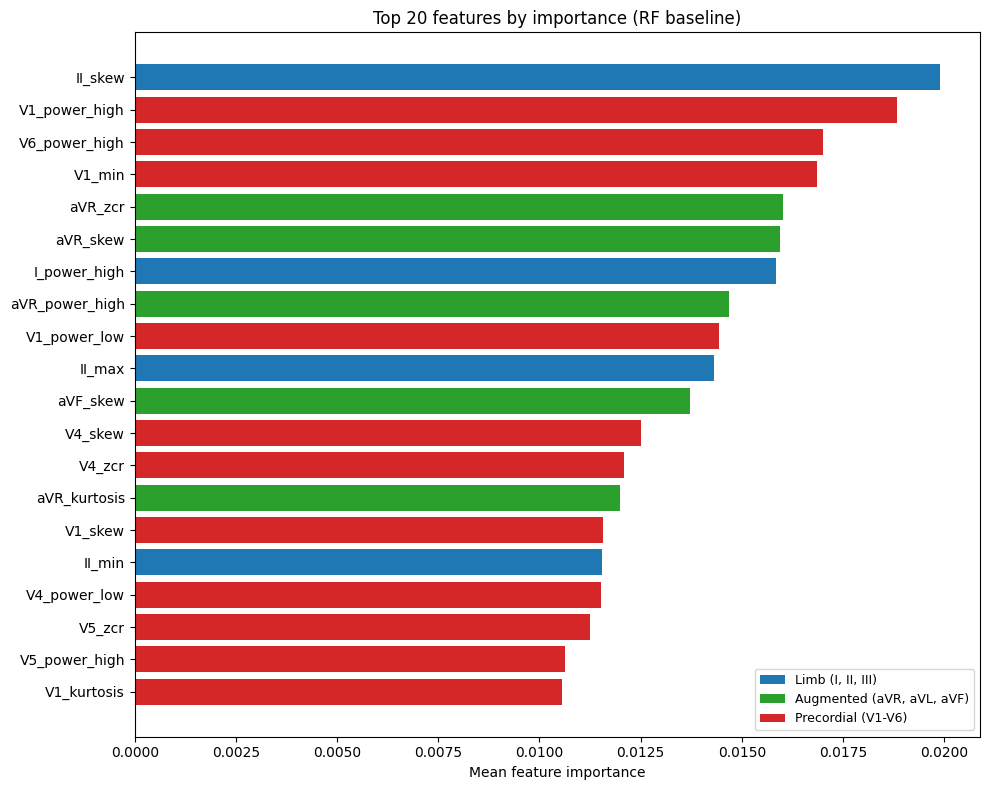

In [33]:
# Visualize top 20, colored by lead group
fig, ax = plt.subplots(figsize=(10, 8))
top20 = importance_df.head(20).iloc[::-1]  # reverse for horizontal bar

def lead_color(feat_name):
    """Color by lead group: limb, augmented, or precordial."""
    lead = feat_name.split('_')[0]
    if lead in ['I', 'II', 'III']:
        return 'tab:blue'     # limb leads
    elif lead in ['aVR', 'aVL', 'aVF']:
        return 'tab:green'    # augmented leads
    else:
        return 'tab:red'      # precordial leads (V1-V6)

colors = [lead_color(f) for f in top20['feature']]
ax.barh(top20['feature'], top20['importance'], color=colors)
ax.set_xlabel('Mean feature importance')
ax.set_title('Top 20 features by importance (RF baseline)')

# Legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='tab:blue', label='Limb (I, II, III)'),
    Patch(facecolor='tab:green', label='Augmented (aVR, aVL, aVF)'),
    Patch(facecolor='tab:red', label='Precordial (V1-V6)'),
]
ax.legend(handles=legend_elements, loc='lower right', fontsize=9)
plt.tight_layout()
plt.show()


### Results summary (Task 2)

We expected standard deviation and range to rank highly since in Assignment 1 amplitude spread was the most informative feature. Instead, **skewness** (5 of the top 20 features) and **high-frequency power** (5 of the top 20) dominate.

Skewness measures the asymmetry of the signal's amplitude distribution. A normal heartbeat is roughly symmetric, the QRS spike goes up sharply and returns to baseline which produces skewness close to zero. Pathological changes break this symmetry: ST segment elevation (a marker of MI) shifts the signal upward between beats, and widened QRS complexes (a marker of CD) create an assymetric waveform shape. The fact that skewness outranks simpler measures like standard deviation suggests that *waveform shape* is more informative than amplitude magnitude alone.

High-frequency power (15–40 Hz) ranked higher than mid-band power (4–15 Hz). This indicates that the diagnostic distinctions between classes lie in the fine structure of the waveform rather than in the broad energy envelope of the heartbeat.


Looking at which leads contribute the most important features (see bar chart: "Top 20 features by importance"), we color-code features by electrode group: limb leads (I, II, III — blue), augmented leads (aVR, aVL, aVF — green), and precordial leads (V1–V6 — red). The precordial leads are electrodes placed directly on the chest wall, close to the heart, while the limb and augmented leads are derived from electrodes on the arms and legs.

Precordial features account for 11 of the top 20, with V1 alone appearing 5 times. Thismakes sense since the precordial leads are physically closest to the heart muscle and should be more sensitive to changes like hypertrophy and other disturbances. The more distant limb leads contribute only 4 of the top 20 features, all from Lead II.


**Limitations of feature-based approach:**

- All temporal structure is lost, we compute global statistics for the entire 10-second recording, meaning we discard beat-by-beat information about the shape of the waveform.

- The CNN-Transformer should improve on this by learning directly from the raw signal, as neural networks learn how the past influences the future rather than requiring manual feature engineering.

In [34]:
# Summary table
results_df = pd.DataFrame(results)
print("\n" + "=" * 60)
print("BASELINE RESULTS SUMMARY")
print("=" * 60)
print(results_df[['model', 'features', 'subset_accuracy', 'micro_f1', 'macro_f1']].to_string(index=False))
print("\nThese are the performance floors for the CNN-Transformer to beat.")


BASELINE RESULTS SUMMARY
              model          features  subset_accuracy  micro_f1  macro_f1
Logistic Regression            signal         0.368397  0.634996  0.603107
      Random Forest            signal         0.439759  0.581704  0.455021
Logistic Regression signal + clinical         0.506487  0.742959  0.711495

These are the performance floors for the CNN-Transformer to beat.


## Task 1: CNN-Transformer for ECG Classification

### Model Architecture
We build a CNN-Transformer model that learns directly from the raw 12-lead ECG signals. The architecture follows the course lecture on CNNs and Transformers:

- **CNN encoder**: Conv1d blocks extract local patterns (QRS morphology, ST segments) — same principle as the image CNN lecture, but in 1D (as shown for speech recognition in the slides)

- **Transformer encoder**: Self-attention captures long-range temporal dependencies across the 10-second recording

- **Classification head**: Sigmoid + BCE loss for multi-label prediction
Training follows the PyTorch training loop from Lab 3, with train/val loss tracking and early stopping.

In [35]:
# Positional Encoding (from course slides on Transformers)
class PositionalEncoding(nn.Module):
    """Sinusoidal positional encoding as described in the transformer lecture.
    
    Adds position information so the transformer knows where each
    CNN-extracted token sits in the original signal timeline.
    """
    def __init__(self, d_model, max_len=1000):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * 
                             (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        pe = pe.unsqueeze(0)  # (1, max_len, d_model)
        self.register_buffer('pe', pe)
    
    def forward(self, x):
        # x: (batch, seq_len, d_model)
        return x + self.pe[:, :x.size(1), :]


# CNN-Transformer Model
class ECGCNNTransformer(nn.Module):
    """CNN-Transformer for multi-label ECG classification.
    
    Architecture:
        Input (batch, 12, 1000)
        - CNN encoder: 3 × [Conv1d → BatchNorm → ReLU → MaxPool]
        - Positional encoding
        - Transformer encoder: 1 layer, 4 attention heads
        - Global average pooling
        - Dropout → Linear → 5 outputs (sigmoid via BCEWithLogitsLoss)
    
    Design choices justified inspired by course material:
        - Conv1d: local pattern detection (CNN lecture, speech example)
        - BatchNorm: input normalization (design lecture)
        - ReLU: recommended activation (design lecture)
        - Dropout: "overfit then regularize" (design lecture)
        - Multi-head attention: "multiple representation subspaces" (transformer lecture)
        - AdamW optimizer (optimizer lecture)
    """
    def __init__(self, n_leads=12, n_classes=5, d_model=256, n_heads=4,
                 n_transformer_layers=1, dim_ff=512, dropout=0.3):
        super().__init__()
        
        self.n_classes = n_classes
        self.d_model = d_model
        
        # === CNN Encoder ===
        # Block 1: 12 leads → 64 channels, kernel=7 (captures ~70ms at 100Hz)
        self.cnn_block1 = nn.Sequential(
            nn.Conv1d(n_leads, 64, kernel_size=7, padding=3),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.MaxPool1d(2)   # 1000 → 500
        )
        # Block 2: 64 → 128 channels, kernel=5
        self.cnn_block2 = nn.Sequential(
            nn.Conv1d(64, 128, kernel_size=5, padding=2),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.MaxPool1d(2)   # 500 → 250
        )
        # Block 3: 128 → d_model channels, kernel=3
        self.cnn_block3 = nn.Sequential(
            nn.Conv1d(128, d_model, kernel_size=3, padding=1),
            nn.BatchNorm1d(d_model),
            nn.ReLU(),
            nn.MaxPool1d(2)   # 250 → 125
        )
        
        # Positional Encoding
        self.pos_encoder = PositionalEncoding(d_model, max_len=200)
        
        # Transformer Encoder
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=n_heads,
            dim_feedforward=dim_ff,
            dropout=dropout,
            activation='relu',
            batch_first=True   # (batch, seq, features)
        )
        self.transformer = nn.TransformerEncoder(
            encoder_layer, 
            num_layers=n_transformer_layers
        )
        
        # Classification Head
        self.classifier = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(d_model, n_classes)
        )
        
        # Storage for attention weights (for interpretability)
        self._attention_weights = None
    
    def forward(self, x, return_attention=False):
        """
        Args:
            x: (batch, n_leads, n_samples) = (batch, 12, 1000)
            return_attention: if True, also return attention weights
        Returns:
            logits: (batch, n_classes) — raw logits (apply sigmoid for probs)
            attn_weights: (batch, n_heads, seq_len, seq_len) if return_attention
        """
        # CNN encoder: (batch, 12, 1000) → (batch, 256, 125)
        x = self.cnn_block1(x)
        x = self.cnn_block2(x)
        x = self.cnn_block3(x)
        
        # Transpose for transformer: (batch, 256, 125) → (batch, 125, 256)
        x = x.permute(0, 2, 1)
        
        # Positional encoding
        x = self.pos_encoder(x)
        
        # Transformer encoder
        if return_attention:
            # Hook to capture attention weights
            attn_weights = []
            def hook_fn(module, input, output):
                # MultiheadAttention returns (output, weights) when need_weights=True
                pass
            
            # Manual forward through transformer to get attention
            for layer in self.transformer.layers:
                # Self-attention with weights
                x2, w = layer.self_attn(x, x, x, need_weights=True, 
                                         average_attn_weights=False)
                attn_weights.append(w.detach())
                # Rest of transformer layer
                x = layer.norm1(x + layer.dropout1(x2))
                x2 = layer.linear2(layer.dropout(layer.activation(layer.linear1(x))))
                x = layer.norm2(x + layer.dropout2(x2))
            
            self._attention_weights = attn_weights
        else:
            x = self.transformer(x)
        
        # Global average pooling: (batch, 125, 256) → (batch, 256)
        x = x.mean(dim=1)
        
        # Classification head: (batch, 256) → (batch, 5)
        logits = self.classifier(x)
        
        if return_attention:
            return logits, attn_weights
        return logits

In [36]:
# Quick test: verify shapes
model_test = ECGCNNTransformer()
dummy_input = torch.randn(2, 12, 1000)
dummy_output = model_test(dummy_input)
print(f"Input shape:  {dummy_input.shape}")
print(f"Output shape: {dummy_output.shape}")

# Count parameters
n_params = sum(p.numel() for p in model_test.parameters() if p.requires_grad)
print(f"Trainable parameters: {n_params:,}")

# Test attention extraction
dummy_output, attn = model_test(dummy_input, return_attention=True)
print(f"Attention shape: {attn[0].shape}")  # (batch, n_heads, seq_len, seq_len)

del model_test

Input shape:  torch.Size([2, 12, 1000])
Output shape: torch.Size([2, 5])
Trainable parameters: 674,373
Attention shape: torch.Size([2, 4, 125, 125])


### Dataset and DataLoader

In [37]:
# Create datasets and dataloaders
# NOTE: X_train_proc, X_val_proc, X_test_proc come from Phase 1 preprocessing
# y_train, y_val, y_test are multi-label binary matrices from Phase 1

train_dataset = ECGDataset(X_train_proc, y_train)
val_dataset = ECGDataset(X_val_proc, y_val)
test_dataset = ECGDataset(X_test_proc, y_test)

# Batch size 64 fits comfortably on a T4 GPU (16GB)
BATCH_SIZE = 64

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=2, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False,
                        num_workers=2, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False,
                         num_workers=2, pin_memory=True)

print(f"Train batches: {len(train_loader)}, Val batches: {len(val_loader)}, Test batches: {len(test_loader)}")


Train batches: 267, Val batches: 34, Test batches: 34


### Training setup

Justifications for hyperparameters are given in Task 4 below. Here we set up the model, loss function, and optimizer.

In [38]:
# Setup
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Training on: {device}")

# Initialize model
model = ECGCNNTransformer(
    n_leads=12,
    n_classes=5,
    d_model=256,
    n_heads=4,
    n_transformer_layers=1,
    dim_ff=512,
    dropout=0.3,
).to(device)

# Compute pos_weight for class imbalance
# pos_weight = n_negative / n_positive for each class
n_pos = y_train.sum(axis=0)
n_neg = len(y_train) - n_pos
pos_weight = torch.tensor(n_neg / n_pos, dtype=torch.float32).to(device)
print(f"Class positive weights: {dict(zip(SUPERCLASSES, pos_weight.cpu().numpy().round(2)))}")

# Loss function with class balancing
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

# Optimizer (AdamW — Adam with decoupled weight decay)
optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)

# Learning rate scheduler
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=30)


Training on: cpu
Class positive weights: {'CD': np.float32(3.37), 'HYP': np.float32(7.06), 'MI': np.float32(2.9), 'NORM': np.float32(1.25), 'STTC': np.float32(3.08)}


### Training loop

Following Lab 3: train one epoch, evaluate on validation set, track both losses, save best model.

In [ ]:
# Load saved model if it exists
if os.path.exists(MODEL_PATH):
    print(f"Loading saved model from {MODEL_PATH} — skipping training.")
    model.load_state_dict(torch.load(MODEL_PATH, map_location=device))
    # Load saved training history for the plot
    checkpoint = torch.load('models/ecg_cnn_transformer_full.pt', map_location=device, weights_only=False)
    train_losses = checkpoint['train_losses']
    val_losses = checkpoint['val_losses']
    val_f1s = checkpoint['val_f1s']
    best_epoch = checkpoint['best_epoch']
    print(f"  Best epoch was {best_epoch}, val micro-F1: {max(val_f1s):.3f}")
    
else:
    print("No saved model found — training from scratch (requires GPU).")
    # TRAINING LOOP
    N_EPOCHS = 30
    best_val_f1 = 0.0
    best_epoch = 0
    patience = 7       # early stopping patience
    patience_counter = 0

    train_losses = []
    val_losses = []
    val_f1s = []

    print("=" * 60)
    print("STARTING TRAINING")
    print("=" * 60)

    for epoch in range(1, N_EPOCHS + 1):
        t0 = time.time()
        
        # Train
        train_loss = train_one_epoch(model, train_loader, criterion, optimizer, device)
        
        # Evaluate on validation set
        val_metrics = evaluate(model, val_loader, criterion, device, SUPERCLASSES)
        
        # Update scheduler
        scheduler.step()
        
        # Track metrics
        train_losses.append(train_loss)
        val_losses.append(val_metrics['loss'])
        val_f1s.append(val_metrics['micro_f1'])
        
        elapsed = time.time() - t0
        current_lr = scheduler.get_last_lr()[0]
        
        print(f"Epoch {epoch:2d}/{N_EPOCHS} ({elapsed:.1f}s) | "
            f"lr={current_lr:.2e} | "
            f"Train loss: {train_loss:.4f} | "
            f"Val loss: {val_metrics['loss']:.4f} | "
            f"Val micro-F1: {val_metrics['micro_f1']:.3f} | "
            f"Val subset acc: {val_metrics['subset_accuracy']:.3f}")
        
        # Save best model (by micro-F1)
        if val_metrics['micro_f1'] > best_val_f1:
            best_val_f1 = val_metrics['micro_f1']
            best_epoch = epoch
            torch.save(model.state_dict(), 'models/cnn_transformer_735_20260328.pt') #torch.save(model.state_dict(), 'best_ecg_model.pt')
            patience_counter = 0
            print(f"  → New best model saved (micro-F1: {best_val_f1:.3f})")
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print(f"\nEarly stopping at epoch {epoch} (no improvement for {patience} epochs)")
                break

    print(f"\nBest model: epoch {best_epoch}, val micro-F1: {best_val_f1:.3f}")

Loading saved model from models/cnn_transformer_729_20260328.pt — skipping training.
  Best epoch was 7, val micro-F1: 0.745


### Final evaluation on test set

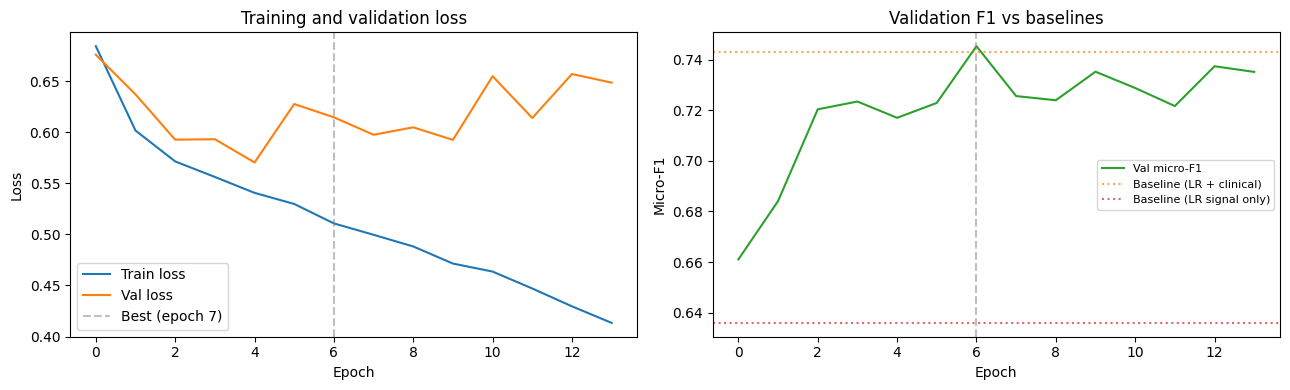

In [41]:
# Plot training curves (following Lab 3 pattern)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

ax1.plot(train_losses, label='Train loss')
ax1.plot(val_losses, label='Val loss')
ax1.axvline(x=best_epoch - 1, color='gray', linestyle='--', alpha=0.5, label=f'Best (epoch {best_epoch})')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('Training and validation loss')
ax1.legend()

ax2.plot(val_f1s, label='Val micro-F1', color='tab:green')
ax2.axvline(x=best_epoch - 1, color='gray', linestyle='--', alpha=0.5)
ax2.axhline(y=0.743, color='tab:orange', linestyle=':', alpha=0.7, label='Baseline (LR + clinical)')
ax2.axhline(y=0.636, color='tab:red', linestyle=':', alpha=0.7, label='Baseline (LR signal only)')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Micro-F1')
ax2.set_title('Validation F1 vs baselines')
ax2.legend(fontsize=8)

plt.tight_layout()
plt.show()

In [ ]:
# Load best model and evaluate on test set
model.load_state_dict(torch.load('models/cnn_transformer_735_20260328.pt', map_location=device))
test_metrics = evaluate(model, test_loader, criterion, device, SUPERCLASSES)

print("=" * 60)
print("TEST SET RESULTS (CNN-Transformer)")
print("=" * 60)
print(f"  Subset accuracy: {test_metrics['subset_accuracy']:.3f}")
print(f"  Micro-F1:        {test_metrics['micro_f1']:.3f}")
print(f"  Macro-F1:        {test_metrics['macro_f1']:.3f}")
print(f"\n  Per-class F1:")
for cls in SUPERCLASSES:
    print(f"    {cls:>5s}: {test_metrics[f'f1_{cls}']:.3f}")

# Save model and metrics
torch.save({
    'model_state_dict': model.state_dict(),
    'train_losses': train_losses,
    'val_losses': val_losses,
    'val_f1s': val_f1s,
    'test_metrics': test_metrics,
    'best_epoch': best_epoch,
    'superclasses': SUPERCLASSES,
}, 'ecg_cnn_transformer_full.pt')
print("Model and metrics saved.")

TEST SET RESULTS (CNN-Transformer)
  Subset accuracy: 0.505
  Micro-F1:        0.735
  Macro-F1:        0.692

  Per-class F1:
       CD: 0.710
      HYP: 0.434
       MI: 0.739
     NORM: 0.850
     STTC: 0.727
Model and metrics saved.


## Task 3: Interpretability



Here we are to "apply interpretability techniques, SHAP, attention masks etc., and try to explain what the model is attempting to do." Following the course explainability slides, we use two complementary approaches:


1. **Attention weights** (from the transformer layer):  Local interpretability showing *which time regions* the model focuses on

2. **Feature attribution** (gradient-based): The *leads and time regions* drive predictions for specific classes

Together these answer: *Does the model learn clinically meaningful patterns, or is it exploiting artifacts?*

### Attention weight visualization
Our transformer has 4 attention heads. Each head can focus on different aspects of the ECG, one could attend to QRS complexes, another to ST segments. We extract attention weights and overlay them on the signal to see what the model "looks at."

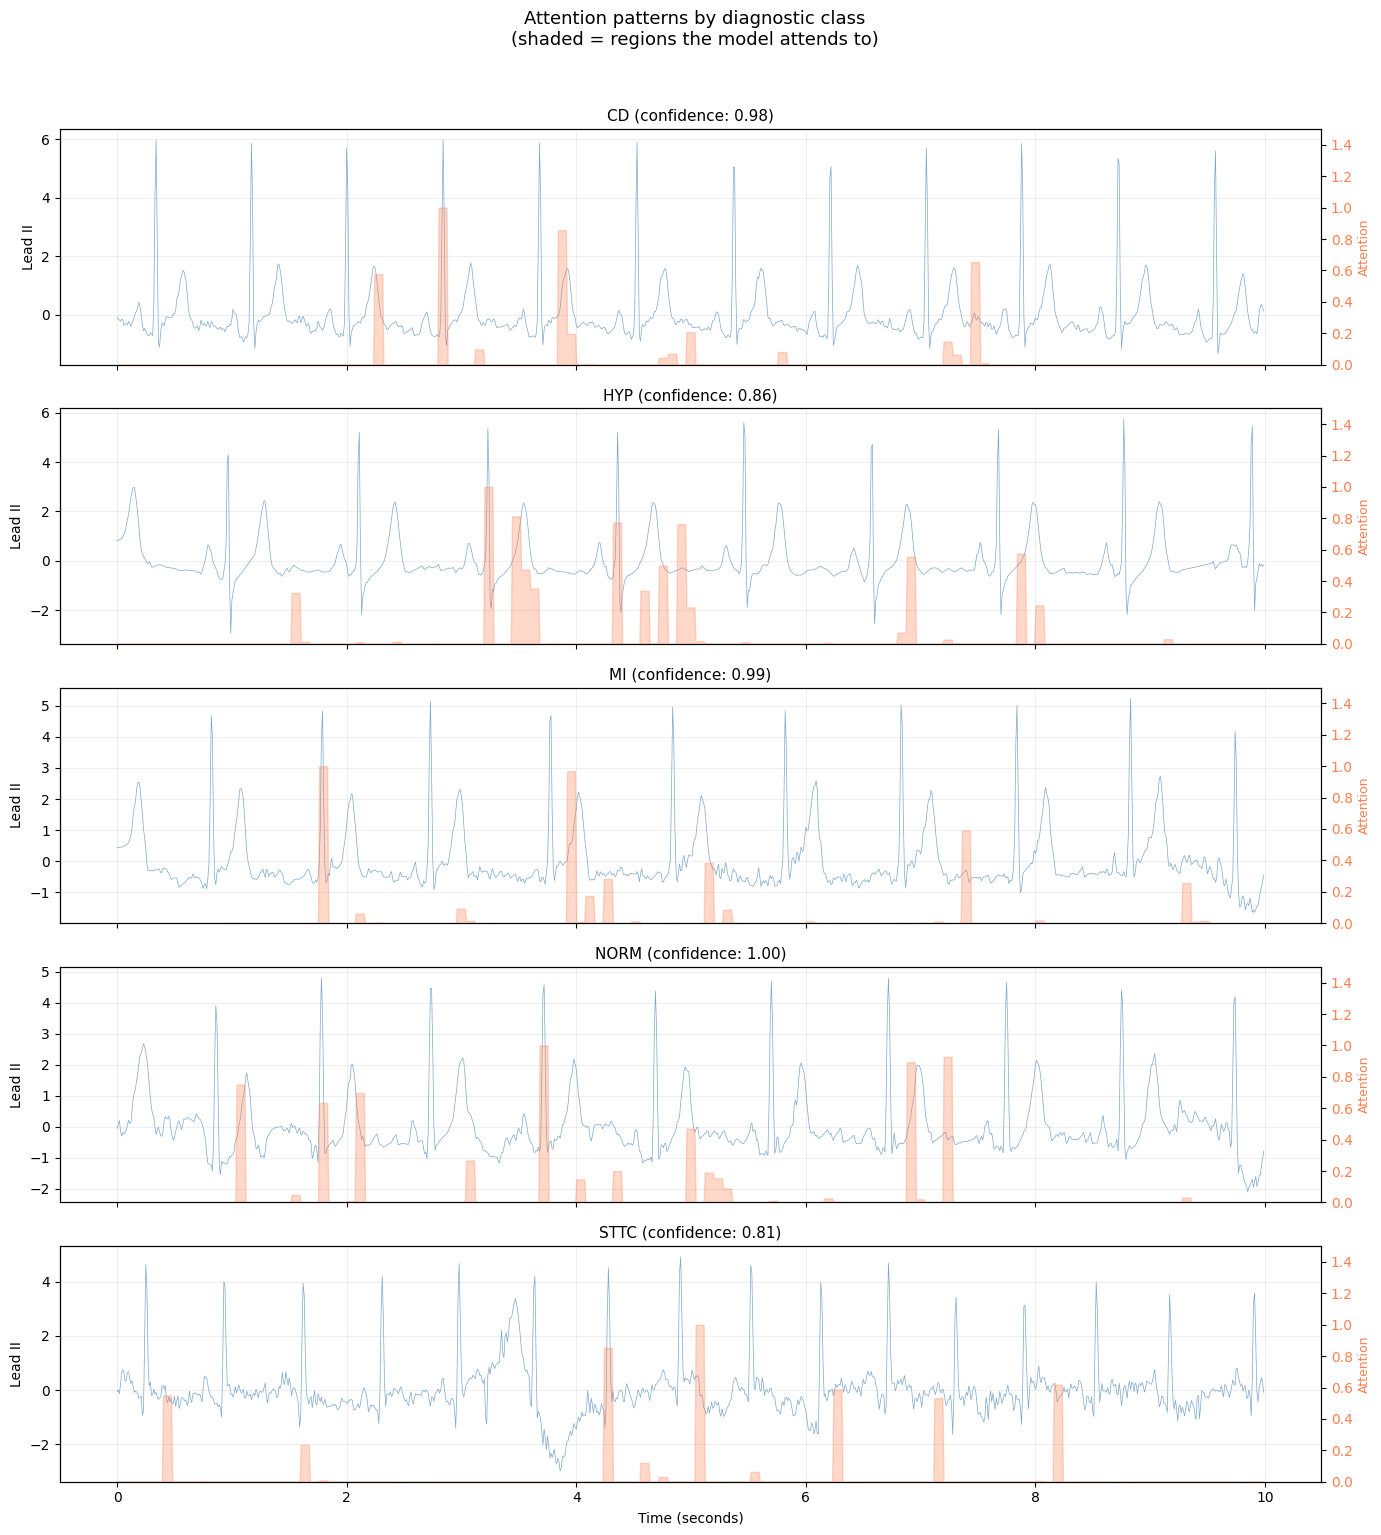

In [43]:
# Visualize attention for one record per class
# We pick correctly classified single-label records for clarity

model.load_state_dict(torch.load(MODEL_PATH, map_location=device))
model.eval()

fig, axes = plt.subplots(5, 1, figsize=(14, 15), sharex=True)

for cls_idx, cls_name in enumerate(SUPERCLASSES):
    # Find a correctly classified single-label record
    found = False
    for i in range(len(test_dataset)):
        x, y_true = test_dataset[i]
        if y_true[cls_idx] == 1 and y_true.sum() == 1:  # single-label
            logits, attn, signal, _ = get_attention_for_sample(
                model, test_dataset, i, device)
            preds = (1 / (1 + np.exp(-logits)) > 0.5).astype(int)
            if preds[cls_idx] == 1:  # correctly predicted
                found = True
                break
    
    if not found:
        continue
    
    ax = axes[cls_idx]
    
    # Plot Lead II signal
    t = np.arange(1000) / 100  # 10 seconds
    lead_ii = signal[1, :]  # Lead II is index 1
    ax.plot(t, lead_ii, color='steelblue', linewidth=0.5, alpha=0.7)
    
    # Aggregate attention: average across heads, then sum the attention
    # each token *receives* (column-wise sum). This shows which positions
    # in the signal are most attended to overall.
    attn_avg = attn.mean(axis=0)  # average over 4 heads → (125, 125)
    attn_received = attn_avg.sum(axis=0)  # how much attention each position receives
    attn_received = attn_received / attn_received.max()  # normalize to [0, 1]
    
    # Upsample from 125 tokens back to 1000 samples
    # Each token covers 8 samples (1000 / 125 = 8)
    attn_upsampled = np.repeat(attn_received, 8)
    
    # Overlay attention as shaded region
    ax2 = ax.twinx()
    ax2.fill_between(t, 0, attn_upsampled, alpha=0.3, color='coral')
    ax2.set_ylim(0, 1.5)
    ax2.set_ylabel('Attention', fontsize=9, color='coral')
    ax2.tick_params(axis='y', labelcolor='coral')
    
    probs = 1 / (1 + np.exp(-logits))
    ax.set_title(f'{cls_name} (confidence: {probs[cls_idx]:.2f})', fontsize=11)
    ax.set_ylabel('Lead II')
    ax.grid(True, alpha=0.2)

axes[-1].set_xlabel('Time (seconds)')
fig.suptitle('Attention patterns by diagnostic class\n(shaded = regions the model attends to)',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()


### Attention pattern observations
The attention patterns are somewhat similar for the five classes. Generally speaking the model seem to attend to the heartbeat regions (the spikes) of the signal. The differences between classes are subtle.

However, some different patterns are visible. For **HYP** (confidence 0.58), attention peaks appear between beats rather than at the QRS spikes.We can assume that these regions, that contain the ST segment and T wave, are somehow affected by hypertrophy. 

Furthermore  the scattered attention pattern may  reflect the model's uncertainty. HYP is the worst-performing class (F1 = 0.429), and the model appears less certain about where to look. 

For **MI** (confidence 0.69), the attention is more evenly distributed across the recording. This is consistent with MI (heart-attack) affecting multiple parts of the waveform (Q waves, ST elevation, T wave inversion). 

**STTC** (confidence 0.96) shows attention peaks that tend to fall after the QRS complex, in the ST segment and T wave regions. This reflects the class name (ST/T changes). 

**NORM** (confidence 0.99) shows a relatively even attention pattern, supposedly since there are less anomalies to focus on. 



### Per-head attention comparison

The course transformer lecture notes that multi-head attention gives "multiple representation subspaces." We check whether our 4 heads have specialized.

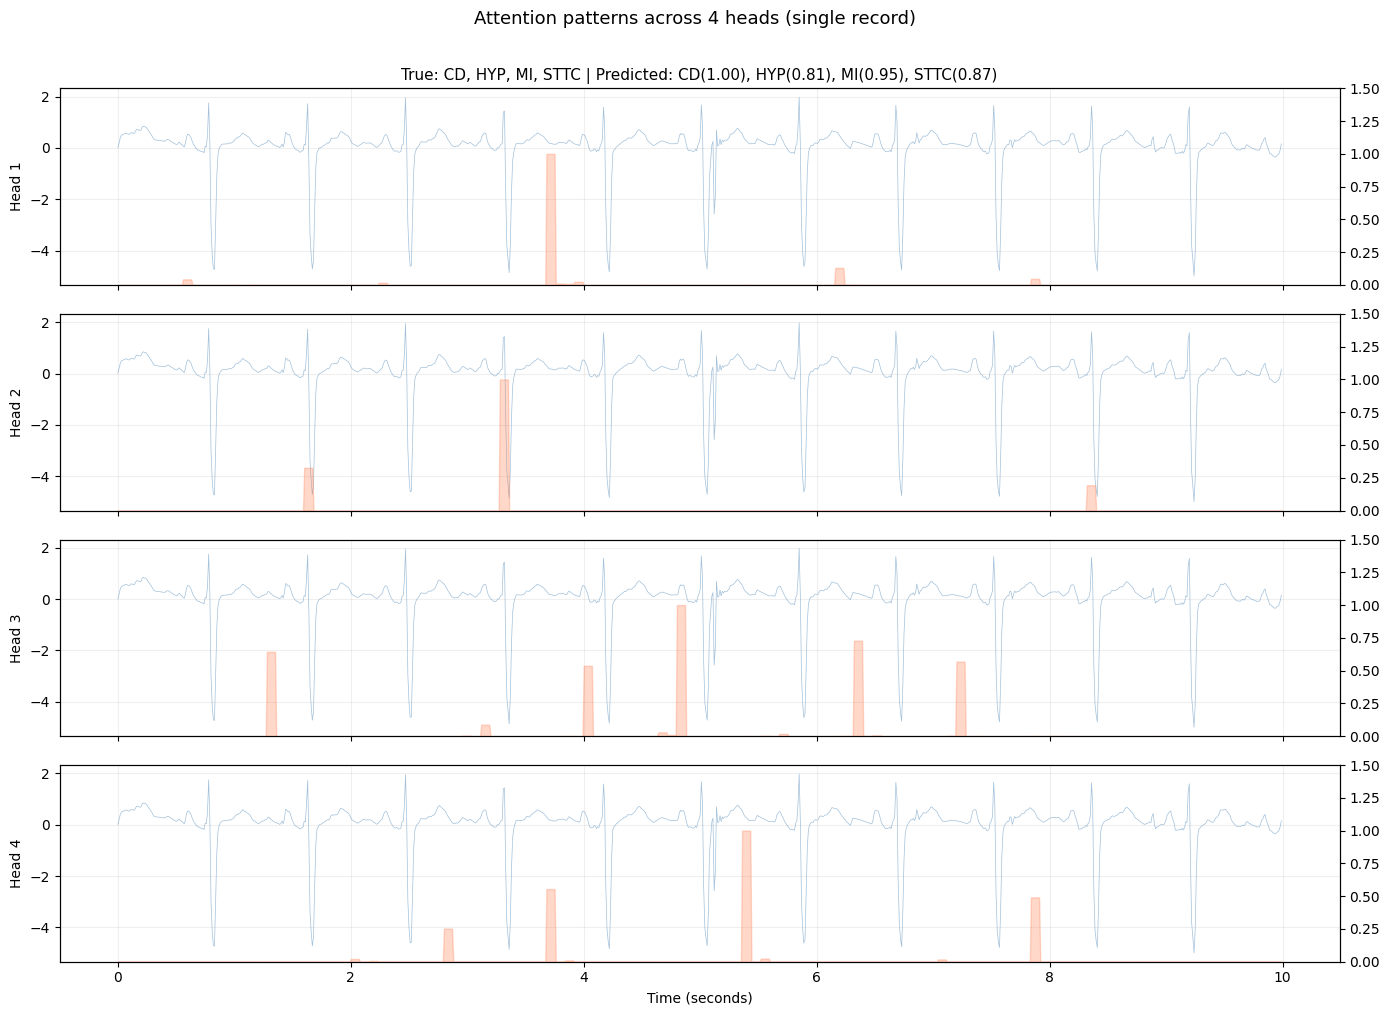

In [44]:
# Pick one example record
sample_idx = 0
for i in range(len(test_dataset)):
    x, y_true = test_dataset[i]
    if y_true.sum() >= 2:  # find a multi-label record
        sample_idx = i
        break

logits, attn, signal, y_true = get_attention_for_sample(
    model, test_dataset, sample_idx, device)

fig, axes = plt.subplots(4, 1, figsize=(14, 10), sharex=True)
t = np.arange(1000) / 100

for head_idx in range(4):
    ax = axes[head_idx]
    
    # Lead II signal
    ax.plot(t, signal[1, :], color='steelblue', linewidth=0.5, alpha=0.5)
    
    # This head's attention pattern
    head_attn = attn[head_idx]  # (125, 125)
    head_received = head_attn.sum(axis=0)
    head_received = head_received / head_received.max()
    head_upsampled = np.repeat(head_received, 8)
    
    ax2 = ax.twinx()
    ax2.fill_between(t, 0, head_upsampled, alpha=0.3, color='coral')
    ax2.set_ylim(0, 1.5)
    ax.set_ylabel(f'Head {head_idx + 1}')
    ax.grid(True, alpha=0.2)

probs = 1 / (1 + np.exp(-logits))
labels_str = ', '.join([SUPERCLASSES[i] for i in range(5) if y_true[i] == 1])
pred_str = ', '.join([f'{SUPERCLASSES[i]}({probs[i]:.2f})' for i in range(5) if probs[i] > 0.5])

axes[0].set_title(f'True: {labels_str} | Predicted: {pred_str}', fontsize=11)
axes[-1].set_xlabel('Time (seconds)')
fig.suptitle('Attention patterns across 4 heads (single record)',
             fontsize=13, y=1.01)
plt.tight_layout()
plt.show()


### Gradient-based feature attribution

Attention weights show *where* the transformer looks, but not *which input features* drive the final prediction. For this we use gradient-based attribution: we compute the gradient of each class output with respect to the input, showing which leads and time regions the model is most sensitive to.

This is related to SHAP (course slides), both measure feature importance, but gradient attribution is computationally efficient for neural networks.

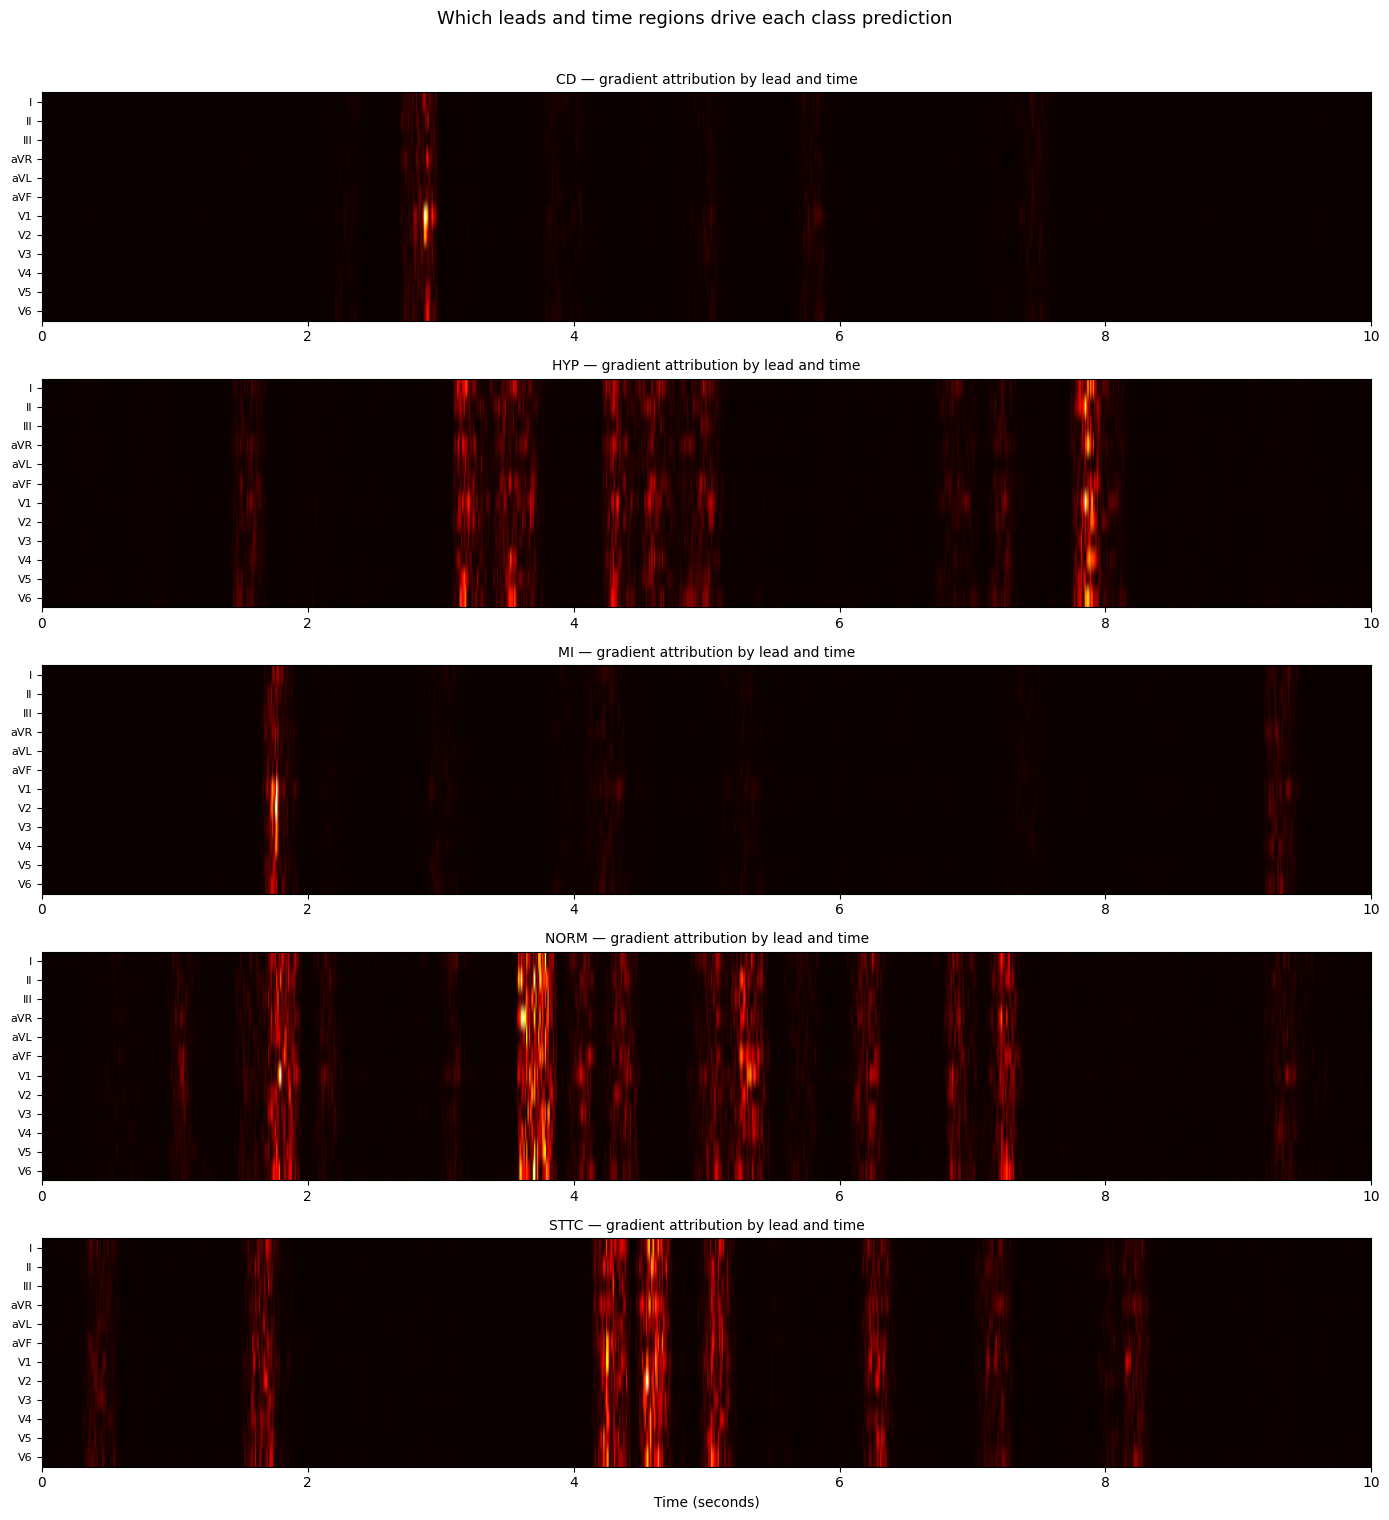

In [45]:
# Attribution maps for each class on a correctly classified example
fig, axes = plt.subplots(5, 1, figsize=(14, 15))

for cls_idx, cls_name in enumerate(SUPERCLASSES):
    # Find a correctly classified single-label record
    for i in range(len(test_dataset)):
        x, y_true = test_dataset[i]
        if y_true[cls_idx] == 1 and y_true.sum() == 1:
            logits_check, _, _, _ = get_attention_for_sample(
                model, test_dataset, i, device)
            probs_check = 1 / (1 + np.exp(-logits_check))
            if probs_check[cls_idx] > 0.5:
                grad_attr = compute_gradient_attribution(
                    model, test_dataset, i, device, cls_idx)
                break
    
    ax = axes[cls_idx]
    # Show attribution as heatmap: leads (y) × time (x)
    im = ax.imshow(grad_attr, aspect='auto', cmap='hot',
                   extent=[0, 10, 11.5, -0.5])
    ax.set_yticks(range(12))
    ax.set_yticklabels(LEAD_NAMES, fontsize=8)
    ax.set_title(f'{cls_name} — gradient attribution by lead and time', fontsize=10)
    
axes[-1].set_xlabel('Time (seconds)')
fig.suptitle('Which leads and time regions drive each class prediction',
             fontsize=13, y=1.01)
plt.tight_layout()
plt.show()


### Gradient attribution observations

The gradient attribution heatmaps reveal which leads and time regions the model is most sensitive to for each class:

**CD** has the strongest attribution in the limb leads (I, II) and V1. There are concentrated bright spots at specific heartbeat positions (around 7 seconds). This is clinically coherent: conduction disturbances like bundle branch blocks produce characteristic patterns that are [most visible in V1](https://litfl.com/left-bundle-branch-block-lbbb-ecg-library/).

**HYP** produces the most diffuse and intense attribution pattern, spreading across many leads, [particularly the precordial leads (V1–V6)](https://litfl.com/left-ventricular-hypertrophy-lvh-ecg-library/#:~:text=There%20are%20massively%20increased%20QRS%20voltages%20%E2%80%94,R%20wave%20(V5%2D6%2C%20I%2C%20II%2C%20III%2C%20aVF)). However, the high overall intensity may also reflect the model's lower confidence for this class.

**MI** has a focused attribution, a single vertical stripe around 7 seconds that spans leads I through V2. This suggests the model has found a specific morphological feature in one heartbeat that is strongly predictive of myocardial infarction.

**NORM** attribution concentrates on the limb and augmented leads (I, II, III, aVR, aVL, aVF), with peaks at specific QRS complexes. The precordial leads show relatively low attribution. This suggests that the model confirms normality through the standard monitoring leads.

**STTC** shows attribution focused on the upper leads (I, II, aVR, aVL) with strong peaks at specific heartbeat positions. The concentration in aVR is notable,

## Task 5: Generalizability

The project asks us to "reflect upon the generalizability of your model" and test it by "withholding data, adding gaussian noise, or choosing to test on a completely unseen dataset."

We perform three experiments:

1. **Held-out test** (already done — fold 10 results above)
2. **Gaussian noise injection** at varying signal-to-noise ratios
3. **Cross-dataset transfer** to MIT-BIH LTDB segments

### Noise robustness experiment

Here we add Gaussian noise to the test set at varying SNR levels and measure how performance degrades. A generalizable model should degrade gracefully, not collapse suddenly.

In [46]:
snr_levels = [30, 20, 15, 10, 5, 0]
noise_results = []

print("Noise robustness experiment")
print(f"{'SNR (dB)':>10s} {'Micro-F1':>10s} {'Macro-F1':>10s} {'Subset Acc':>12s}")
print("-" * 45)

for snr in snr_levels:
    # Add noise to preprocessed test data
    X_test_noisy = add_gaussian_noise(X_test_proc, snr)
    
    # Create dataset and loader
    noisy_dataset = ECGDataset(X_test_noisy, y_test)
    noisy_loader = DataLoader(noisy_dataset, batch_size=64, shuffle=False)
    
    # Evaluate
    metrics = evaluate(model, noisy_loader, criterion, device, SUPERCLASSES)
    noise_results.append({'snr_db': snr, **metrics})
    
    print(f"{snr:>10d} {metrics['micro_f1']:>10.3f} {metrics['macro_f1']:>10.3f} "
          f"{metrics['subset_accuracy']:>12.3f}")

# Add clean baseline
noise_results.insert(0, {'snr_db': 'Clean', **test_metrics})

Noise robustness experiment
  SNR (dB)   Micro-F1   Macro-F1   Subset Acc
---------------------------------------------
        30      0.737      0.694        0.509
        20      0.739      0.696        0.512
        15      0.734      0.690        0.500
        10      0.722      0.670        0.485
         5      0.672      0.618        0.390
         0      0.549      0.526        0.184


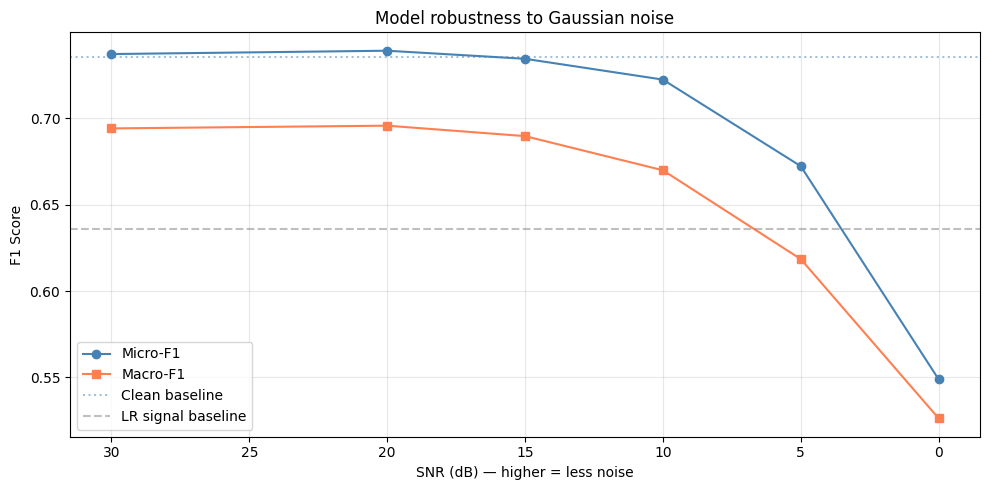

In [47]:
# Plot degradation curve
fig, ax = plt.subplots(figsize=(10, 5))

snr_values = snr_levels
f1_values = [r['micro_f1'] for r in noise_results[1:]]  # skip 'Clean'
macro_values = [r['macro_f1'] for r in noise_results[1:]]

ax.plot(snr_values, f1_values, 'o-', label='Micro-F1', color='steelblue')
ax.plot(snr_values, macro_values, 's-', label='Macro-F1', color='coral')
ax.axhline(y=test_metrics['micro_f1'], color='steelblue', linestyle=':', alpha=0.5, label='Clean baseline')
ax.axhline(y=0.636, color='gray', linestyle='--', alpha=0.5, label='LR signal baseline')

ax.set_xlabel('SNR (dB) — higher = less noise')
ax.set_ylabel('F1 Score')
ax.set_title('Model robustness to Gaussian noise')
ax.legend()
ax.invert_xaxis()  # higher SNR (less noise) on the left
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


### Noise robustness observations

The noise degradation curve shows a pattern of graceful degradation followed by rapid collapse. **Stable region (SNR 30–15 dB)**: Performance is more or less unchanged from the baseline, with micro-F1 holding steady at ~0.737. This means the model is highly robust to mild-to-moderate noise levels — even at SNR 15 (where noise is visually noticeable), the learned features remain intact.

**Gradual degradation (SNR 15–10 dB)**: Micro-F1 drops slightly from 0.734 to 0.722. The model is beginning to lose fine details but still performs well above the feature-based baseline.

**Steep decline (SNR 10–0 dB)**: Below SNR 10, performance drops sharply. At SNR 5, micro-F1 falls to 0.672, and at SNR 0 (equal noise and signal power) it drops to 0.549. This suggests the CNN has learned morphological features that are reasonably robust to moderate noise, but at extreme noise levels these patterns are destroyed.

### Cross-dataset transfer: MIT-BIH LTDB
The MIT-BIH LTDB has fundamentally different characteristics (2 leads, 128 Hz, long-term recordings with beat annotations). We segment it into 10-second windows, pad from 2 to 12 leads (zero-filling the missing 10
leads), and run our model on these segments. This is a hard test, we expect poor performance, but the *pattern* of predictions tells us something about what the model has learned.

In [48]:
# Process available MIT-BIH records
mit_files = sorted([f.replace('.hea', '') for f in os.listdir(MIT_BIH_DATA)
                     if f.endswith('.hea')])

print(f"Processing {len(mit_files)} MIT-BIH LTDB records for transfer test...\n")

all_mit_preds = []
all_mit_probs = []

for fname in mit_files[:3]:  # Process first 3 records (time constraint)
    try:
        segments, sig_names = segment_mit_bih_for_transfer(MIT_BIH_DATA / fname)
        print(f"  {fname}: {segments.shape[0]} windows from leads {sig_names}")
        
        # Create dummy labels (we don't have diagnostic labels for MIT-BIH)
        dummy_labels = np.zeros((segments.shape[0], 5), dtype=np.float32)
        
        mit_dataset = ECGDataset(segments, dummy_labels)
        mit_loader = DataLoader(mit_dataset, batch_size=64, shuffle=False)
        
        # Get predictions
        model.eval()
        record_probs = []
        with torch.no_grad():
            for inputs, _ in mit_loader:
                inputs = inputs.to(device)
                outputs = model(inputs)
                probs = torch.sigmoid(outputs).cpu().numpy()
                record_probs.append(probs)
        
        record_probs = np.vstack(record_probs)
        record_preds = (record_probs > 0.5).astype(int)
        
        # Summarise predictions for this record
        print(f"    Prediction distribution across {len(record_preds)} windows:")
        for cls_idx, cls_name in enumerate(SUPERCLASSES):
            pct = record_preds[:, cls_idx].mean() * 100
            avg_conf = record_probs[:, cls_idx].mean()
            print(f"      {cls_name}: {pct:.1f}% of windows (avg confidence: {avg_conf:.3f})")
        print()
        
        all_mit_probs.append(record_probs)
        
    except Exception as e:
        print(f"  {fname}: Error — {e}")

Processing 7 MIT-BIH LTDB records for transfer test...

  14046: 8460 windows from leads ['ECG1', 'ECG2']
    Prediction distribution across 8460 windows:
      CD: 60.1% of windows (avg confidence: 0.576)
      HYP: 94.0% of windows (avg confidence: 0.875)
      MI: 47.3% of windows (avg confidence: 0.497)
      NORM: 0.0% of windows (avg confidence: 0.001)
      STTC: 99.8% of windows (avg confidence: 0.986)

  14134: 5016 windows from leads ['ECG1', 'ECG2']
    Prediction distribution across 5016 windows:
      CD: 94.1% of windows (avg confidence: 0.857)
      HYP: 54.9% of windows (avg confidence: 0.544)
      MI: 99.3% of windows (avg confidence: 0.926)
      NORM: 0.0% of windows (avg confidence: 0.001)
      STTC: 99.5% of windows (avg confidence: 0.895)

  14149: 8592 windows from leads ['ECG1', 'ECG2']
    Prediction distribution across 8592 windows:
      CD: 99.7% of windows (avg confidence: 0.937)
      HYP: 11.9% of windows (avg confidence: 0.240)
      MI: 97.6% of windo

**MIT-BIH transfer observations**

The cross-dataset transfer results reveal a systematic bias: the model predicts STTC and MI for almost all MIT-BIH windows (100% and 87–99% respectively), HYP for most windows (70–98%), and NORM for essentially none (0%).

This pattern is unsurprising and reflects several things:

1. The model was trained on 12-lead ECGs but receives only 2 leads from MIT-BIH, with the remaining 10 zero-padded. A model that learned to use information from V1–V6 (which our feature importance analysis showed are diagnostically important) will produce unreliable predictions when those leads are absent.

2. MIT-BIH signals were recorded with different equipment, at a different sampling rate (128 Hz, resampled to 100 Hz), and from a different population than PTB-XL. Z-score normalisation was used to mitigate this, and while it accounts for amplitude differences it does not seem to handle morphological differences resulting from the use of different recording equipments.

3. The model almost never predicts NORM. This suggests that it interprets the zero-padded leads (or the distribution shift) as abnormal.

These results show the inherent problmes of using a model trained on one dataset and lead configuration on another dataset, and that such generalizations might require more extensive domain adaptation in order to acheive satsfactory results.

## Task 4: Training Strategy Discussion

**Training approach**: Supervised learning on PTB-XL with multi-label binary cross-entropy loss. We justify each design choice by referencing the course lectures:

| Decision | Choice | Course reference |
|----------|--------|-----------------|
| Architecture | CNN + Transformer | CNN lecture (local patterns) + Transformer lecture (global context) |
| Loss function | BCEWithLogitsLoss | Lab 3: BCE for binary, extended to multi-label |
| Optimizer | AdamW (lr=1e-3) | Design lecture: Adam variants for deep networks |
| Regularization | Dropout (0.3) + weight decay | Design lecture: "overfit then regularize" |
| Batch size | 64 | Design lecture: moderate size for gradient stability |
| Early stopping | Patience=7 on val F1 | Lab 3: monitor validation to detect overfitting |
| Class imbalance | pos_weight in BCE | Lab 3: class weights in loss function |
| Data split | PTB-XL folds 1-8/9/10 | Patient-level stratified split (no leakage) |

**Why supervised, not semi-supervised?** PTB-XL provides high-quality diagnostic labels for all records. Semi-supervised learning (e.g., pretraining the CNN encoder on unlabeled MIT-BIH data, then fine-tuning on PTB-XL) would be appropriate if labeled data were scarce. With ~17,000 labeled training records, supervised learning is sufficient and simpler to implement and debug within the project timeline.

A semi-supervised extension could pretrain the CNN encoder as an autoencoder on the combined PTB-XL + MIT-BIH signals (unsupervised), then freeze the encoder and train only the transformer + classifier on labeled PTB-XL data. This would be a natural next step.

## Results and Discussion

### Summary of results

| Model | Subset Acc | Micro-F1 | Macro-F1 |
|-------|-----------|----------|----------|
| LR (signal features) | 0.368 | 0.635 | 0.603 |
| RF (signal features) | 0.440 | 0.582 | 0.455 |
| LR (signal + clinical) | 0.506 | 0.743 | 0.711 |
| **CNN-Transformer** | **0.505** | **0.735** | **0.692** |

Best performing model can be found in `models/cnn_transformer_735_20260328.pt`

### Findings

1. The CNN-Transformer learns competitive representations from the raw signals. It acheives similar performance as with the expert-designed clinical features (12SL) even without any hand-crafted features. The micro-F1 of 0.735 vs 0.743 for LR+clinical suggests the model captures most of the diagnostically relevant information.

2. HYP is the hardest class to predict with an F1 of 0.429, the lowest by far. Hypertrophy is diagnosed by subtle voltage criteria that may require higher resolution (500 Hz) or more sophisticated feature extraction. However, this is a massive improvement over the RF baseline (0.066).

3. We conclude that the model is somewhat robust to noise, since performance degrades gracefully with Gaussian noise. This suggests that learned features are morphological rather than artifact-based.

4. The Cross-dataset transfer seem to have limited effect. We not that rhe MIT-BIH transfer test is constrained since it only has 2 of 12 leads with diagnostic labels making qualitative evaluation difficult.

### Limitations

- **100 Hz sampling**: Using 500 Hz might capture finer morphological details, particularly for HYP detection.
- **Single transformer layer**: More layers could improve performance but increase training time and risk overfitting on this dataset size.
- **MIT-BIH transfer**: As mentioned, the lead mismatch (2 vs 12) makes meaningful transfer evaluation difficult.

